# ARX 512 Baseline V7

ARX(5,1,2), 16 augmented inputs, missing-data handling, Ridge alpha search, z-score normalization, intercept, free-run clip.

Chuỗi này tương ứng với folder `ARX_Model_Version 221`, nhưng cố định order là `ARX(5,1,2)`.


## 1. Import và cấu hình


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = Path.cwd()
PROJECT_ROOT = WORK_DIR.parent if WORK_DIR.name.startswith("ARX_Model_Version") else WORK_DIR
VERSION_DIR = PROJECT_ROOT / "ARX_Model_Version 512"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from arx_pipeline import (
    DataConfig,
    SplitConfig,
    ModelConfig,
    load_or_generate_data,
    split_time_series,
    summarize_dataset_behavior,
    build_regression_matrix,
    estimate_ols,
    evaluate_slice,
    compute_ar_roots,
    compute_metrics,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

VERSION_NUMBER = 7
VERSION_NAME = "v7_512_missing_augmented_zscore_intercept_ridge_clip"
USE_AUGMENTED = True
USE_ZSCORE = True
USE_RIDGE = True
USE_CLIP = True
INCLUDE_INTERCEPT = True
RIDGE_ALPHAS = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
CLIP_QUANTILES = (0.01, 0.99)


## 2. Load data


### 2.1 Kiểm tra và xử lý missing data

Dữ liệu hiện tại được sinh tự động nên kỳ vọng không có missing. Tuy nhiên, V7 bổ sung bước kiểm tra và xử lý missing để pipeline phù hợp hơn khi chuyển sang dữ liệu cảm biến thật. Biến cảm biến liên tục được nội suy tuyến tính; biến điều khiển 0/1 được điền theo trạng thái gần nhất và ép về 0/1.

In [2]:
DATA_CONFIG = DataConfig(
    csv_path=PROJECT_ROOT / "greenhouse_data.csv",
    generator_script_path=PROJECT_ROOT / "data_generator.py",
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
)

SPLIT_CONFIG = SplitConfig(train_ratio=0.75, val_ratio=0.15)

BASELINE_INPUT_COLS = (
    "Temperature",
    "Humidity",
    "Light",
    "Drip",
    "Mist",
    "Fan",
)

AUGMENTED_INPUT_COLS = (
    *BASELINE_INPUT_COLS,
    "Light_log",
    "Temp_x_Humi",
    "Temp_x_Light",
    "Humi_x_Light",
    "SP_Center",
    "SP_Width",
    "Month_sin",
    "Month_cos",
    "Season_sin",
    "Season_cos",
)

df_full_raw, true_params, data_source = load_or_generate_data(DATA_CONFIG)

NUMERIC_SENSOR_COLS = [
    "Soil_Moisture",
    "Temperature",
    "Humidity",
    "Light",
    "Soil_Low_SP",
    "Soil_High_SP",
]
BINARY_CONTROL_COLS = ["Drip", "Mist", "Fan"]
TIME_CONTEXT_COLS = ["Month"]
CATEGORICAL_COLS = ["Season"]
MISSING_CHECK_COLS = NUMERIC_SENSOR_COLS + BINARY_CONTROL_COLS + TIME_CONTEXT_COLS + CATEGORICAL_COLS


def missing_report(df_in: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for col in MISSING_CHECK_COLS:
        if col not in df_in.columns:
            continue
        n_missing = int(df_in[col].isna().sum())
        rows.append({
            "stage": label,
            "column": col,
            "missing_count": n_missing,
            "missing_pct": 100.0 * n_missing / max(len(df_in), 1),
        })
    return pd.DataFrame(rows)


def handle_missing_data(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    if "Timestamp" in df.columns:
        df = df.sort_values("Timestamp").reset_index(drop=True)

    # Cảm biến liên tục: nội suy tuyến tính theo thứ tự thời gian.
    continuous_cols = [col for col in NUMERIC_SENSOR_COLS if col in df.columns]
    if continuous_cols:
        df[continuous_cols] = (
            df[continuous_cols]
            .astype(float)
            .interpolate(method="linear", limit_direction="both")
            .ffill()
            .bfill()
        )

    # Tín hiệu điều khiển rời rạc: giữ trạng thái gần nhất rồi ép về 0/1.
    binary_cols = [col for col in BINARY_CONTROL_COLS if col in df.columns]
    for col in binary_cols:
        df[col] = df[col].ffill().bfill().fillna(0).astype(float).round().clip(0, 1)

    # Ngữ cảnh thời gian: điền gần nhất, sau đó ép kiểu phù hợp.
    if "Month" in df.columns:
        df["Month"] = df["Month"].ffill().bfill().fillna(1).astype(int)
    if "Season" in df.columns:
        df["Season"] = df["Season"].ffill().bfill().fillna("unknown")

    return df


missing_before = missing_report(df_full_raw, "before_handling")
df_full = handle_missing_data(df_full_raw)
missing_after = missing_report(df_full, "after_handling")
missing_summary = pd.concat([missing_before, missing_after], ignore_index=True)

df_train_raw, df_val_raw, df_test_raw = split_time_series(df_full, SPLIT_CONFIG)

overview = pd.DataFrame([
    summarize_dataset_behavior(df_full, "Full"),
    summarize_dataset_behavior(df_train_raw, "Train"),
    summarize_dataset_behavior(df_val_raw, "Validation"),
    summarize_dataset_behavior(df_test_raw, "Test"),
])

print("Nguồn dữ liệu:", data_source)
print("Số dòng:", len(df_full), "| Train:", len(df_train_raw), "| Validation:", len(df_val_raw), "| Test:", len(df_test_raw))
display(missing_summary)
overview


Nguồn dữ liệu: CSV:greenhouse_data.csv
Số dòng: 105120 | Train: 78840 | Validation: 15768 | Test: 10512


,stage,column,missing_count,missing_pct
0,before_handling,Soil_Moisture,0,0.0
1,before_handling,Temperature,0,0.0
2,before_handling,Humidity,0,0.0
3,before_handling,Light,0,0.0
4,before_handling,Soil_Low_SP,0,0.0
5,before_handling,Soil_High_SP,0,0.0
6,before_handling,Drip,0,0.0
7,before_handling,Mist,0,0.0
8,before_handling,Fan,0,0.0
9,before_handling,Month,0,0.0


,label,rows,timestamp_start,timestamp_end,months_present,seasons_present,drip_on_pct,drip_switches,mist_on_pct,mist_switches,fan_on_pct,fan_switches,below_sp_pct,inside_sp_pct,above_sp_pct
0,Full,105120,2025-01-01 00:00:00,2025-12-31 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[autumn, spring, summer, winter]",22.80,12533,7.89,8022,16.89,12768,23.09,76.35,0.56
1,Train,78840,2025-01-01 00:00:00,2025-10-01 17:55:00,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[autumn, spring, summer, winter]",23.11,9476,8.33,6324,17.81,9940,23.49,75.97,0.54
2,Validation,15768,2025-10-01 18:00:00,2025-11-25 11:55:00,"[10, 11]",[autumn],22.33,1869,7.45,1158,16.43,1910,22.43,77.08,0.49
3,Test,10512,2025-11-25 12:00:00,2025-12-31 23:55:00,"[11, 12]","[autumn, winter]",21.16,1188,5.24,540,10.74,918,21.05,78.11,0.84


## 3. Feature set


In [3]:
def build_augmented_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df["Light_log"] = np.log1p(df["Light"].clip(lower=0))
    df["Temp_x_Humi"] = df["Temperature"] * df["Humidity"]
    df["Temp_x_Light"] = df["Temperature"] * df["Light_log"]
    df["Humi_x_Light"] = df["Humidity"] * df["Light_log"]
    df["SP_Center"] = 0.5 * (df["Soil_Low_SP"] + df["Soil_High_SP"])
    df["SP_Width"] = df["Soil_High_SP"] - df["Soil_Low_SP"]
    df["Month_sin"] = np.sin(2.0 * np.pi * df["Month"] / 12.0)
    df["Month_cos"] = np.cos(2.0 * np.pi * df["Month"] / 12.0)
    season_map = {"spring": 0, "summer": 1, "autumn": 2, "winter": 3}
    season_num = df["Season"].map(season_map).fillna(0).astype(float)
    df["Season_sin"] = np.sin(2.0 * np.pi * season_num / 4.0)
    df["Season_cos"] = np.cos(2.0 * np.pi * season_num / 4.0)
    return df


df_model = build_augmented_df(df_full) if USE_AUGMENTED else df_full.copy()
df_train, df_val, df_test = split_time_series(df_model, SPLIT_CONFIG)
INPUT_COLS = AUGMENTED_INPUT_COLS if USE_AUGMENTED else BASELINE_INPUT_COLS
SCALE_COLS = ("Soil_Moisture", *INPUT_COLS)

display(pd.Series({
    "use_augmented": USE_AUGMENTED,
    "n_inputs": len(INPUT_COLS),
    "inputs": list(INPUT_COLS),
}))


use_augmented                                                 True
n_inputs                                                        16
inputs           [Temperature, Humidity, Light, Drip, Mist, Fan...
dtype: object

## 4. Normalization và clip


In [4]:
scale_stats = {}
for col in SCALE_COLS:
    mean = float(df_train[col].astype(float).mean())
    std = float(df_train[col].astype(float).std(ddof=0))
    if not np.isfinite(std) or std < 1e-12:
        std = 1.0
    scale_stats[col] = {"mean": mean, "std": std}


def apply_zscore(df_in: pd.DataFrame, stats: dict[str, dict[str, float]]) -> pd.DataFrame:
    df_out = df_in.copy()
    if not USE_ZSCORE:
        return df_out
    for col, st in stats.items():
        df_out[col] = (df_out[col].astype(float) - st["mean"]) / st["std"]
    return df_out


def inverse_y(values: np.ndarray) -> np.ndarray:
    if not USE_ZSCORE:
        return np.asarray(values, dtype=float)
    st = scale_stats["Soil_Moisture"]
    return np.asarray(values, dtype=float) * st["std"] + st["mean"]


clip_low_real = float(df_train["Soil_Moisture"].quantile(CLIP_QUANTILES[0]))
clip_high_real = float(df_train["Soil_Moisture"].quantile(CLIP_QUANTILES[1]))
if USE_ZSCORE:
    y_scale = scale_stats["Soil_Moisture"]
    clip_bounds_model = (
        float((clip_low_real - y_scale["mean"]) / y_scale["std"]),
        float((clip_high_real - y_scale["mean"]) / y_scale["std"]),
    )
else:
    clip_bounds_model = (clip_low_real, clip_high_real)

simulation_clip = clip_bounds_model if USE_CLIP else None

df_train_m = apply_zscore(df_train, scale_stats)
df_val_m = apply_zscore(df_val, scale_stats)
df_test_m = apply_zscore(df_test, scale_stats)

MODEL_CONFIG = ModelConfig(
    na=5,
    nb=1,
    nk=2,
    include_intercept=INCLUDE_INTERCEPT,
    input_cols=INPUT_COLS,
    output_col="Soil_Moisture",
    simulation_clip=simulation_clip,
)

display(pd.Series({
    "use_zscore": USE_ZSCORE,
    "use_clip": USE_CLIP,
    "clip_low_real": clip_low_real,
    "clip_high_real": clip_high_real,
    "clip_low_model": None if simulation_clip is None else simulation_clip[0],
    "clip_high_model": None if simulation_clip is None else simulation_clip[1],
}))
MODEL_CONFIG


use_zscore              True
use_clip                True
clip_low_real      50.667918
clip_high_real     64.567843
clip_low_model     -2.111235
clip_high_model     2.116752
dtype: object

ModelConfig(na=5, nb=1, nk=2, include_intercept=True, input_cols=('Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan', 'Light_log', 'Temp_x_Humi', 'Temp_x_Light', 'Humi_x_Light', 'SP_Center', 'SP_Width', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos'), output_col='Soil_Moisture', simulation_clip=(-2.111235076388017, 2.116751558855979))

## 5. Fit model


In [5]:
X_train, y_train = build_regression_matrix(df_train_m, MODEL_CONFIG)
theta_ols, cov_ols, sigma2_ols = estimate_ols(X_train, y_train)


def estimate_ridge(x_mat: np.ndarray, y_vec: np.ndarray, alpha: float, penalize_intercept: bool = False) -> np.ndarray:
    n_params = x_mat.shape[1]
    penalty = np.eye(n_params, dtype=float)
    if not penalize_intercept and MODEL_CONFIG.include_intercept:
        penalty[-1, -1] = 0.0
    return np.linalg.pinv(x_mat.T @ x_mat + float(alpha) * penalty) @ x_mat.T @ y_vec


def sigma2_for_theta(x_mat: np.ndarray, y_vec: np.ndarray, theta: np.ndarray) -> float:
    resid = y_vec - x_mat @ theta
    return float(np.dot(resid, resid) / max(1, len(y_vec) - len(theta)))


def evaluate_real(split_name: str, df_split: pd.DataFrame, theta: np.ndarray) -> dict:
    ev = evaluate_slice(split_name, df_split, theta, MODEL_CONFIG, true_theta=None, n_step=12)
    arrays = ev["arrays"]
    return {
        "eval": ev,
        "metrics_1step_real": compute_metrics(inverse_y(arrays["y_true_1step"]), inverse_y(arrays["y_pred_1step"]), len(theta)),
        "metrics_12step_real": compute_metrics(inverse_y(arrays["y_true_sim"]), inverse_y(arrays["y_pred_n_step"]), len(theta)),
        "metrics_sim_real": compute_metrics(inverse_y(arrays["y_true_sim"]), inverse_y(arrays["y_pred_sim"]), len(theta)),
    }


theta_by_alpha = {}
search_rows = []
alphas = RIDGE_ALPHAS if USE_RIDGE else [0.0]
for alpha in alphas:
    theta = theta_ols if alpha == 0.0 else estimate_ridge(X_train, y_train, alpha)
    theta_by_alpha[float(alpha)] = theta
    train_result = evaluate_real("Train", df_train_m, theta)
    val_result = evaluate_real("Validation", df_val_m, theta)
    test_result = evaluate_real("Test", df_test_m, theta)
    search_rows.append({
        "alpha": float(alpha),
        "train_FIT_sim": train_result["metrics_sim_real"]["FIT"],
        "val_FIT_1step": val_result["metrics_1step_real"]["FIT"],
        "val_FIT_12step": val_result["metrics_12step_real"]["FIT"],
        "val_FIT_sim": val_result["metrics_sim_real"]["FIT"],
        "val_RMSE_sim": val_result["metrics_sim_real"]["RMSE"],
        "test_FIT_sim": test_result["metrics_sim_real"]["FIT"],
        "test_RMSE_sim": test_result["metrics_sim_real"]["RMSE"],
        "theta_l2": float(np.linalg.norm(theta)),
    })

alpha_search_df = pd.DataFrame(search_rows).sort_values(
    ["val_FIT_sim", "val_FIT_12step", "val_FIT_1step"],
    ascending=[False, False, False],
).reset_index(drop=True)

best_alpha = float(alpha_search_df.iloc[0]["alpha"])
theta_hat = theta_by_alpha[best_alpha]
sigma2_hat = sigma2_for_theta(X_train, y_train, theta_hat)

matrix_info = pd.Series({
    "x_train_shape": X_train.shape,
    "y_train_shape": y_train.shape,
    "rank_x_train": int(np.linalg.matrix_rank(X_train)),
    "condition_number_xtx": float(np.linalg.cond(X_train.T @ X_train)),
    "sigma2_ols": float(sigma2_ols),
    "sigma2_selected": float(sigma2_hat),
})

display(matrix_info)
alpha_search_df.round(6)


x_train_shape                     (78835, 22)
y_train_shape                        (78835,)
rank_x_train                               21
condition_number_xtx    4472723214447855104.0
sigma2_ols                           0.015531
sigma2_selected                      0.015531
dtype: object

,alpha,train_FIT_sim,val_FIT_1step,val_FIT_12step,val_FIT_sim,val_RMSE_sim,test_FIT_sim,test_RMSE_sim,theta_l2
0,0.000000,70.933756,85.542541,67.472409,66.593089,0.950995,65.009388,1.008597,1.077952
1,0.000001,70.933756,85.542541,67.472409,66.593089,0.950995,65.009388,1.008597,1.077952
2,0.000010,70.933756,85.542541,67.472409,66.593089,0.950995,65.009388,1.008597,1.077952
3,0.000100,70.933756,85.542541,67.472409,66.593089,0.950995,65.009388,1.008597,1.077952
4,0.001000,70.933755,85.542541,67.472407,66.593088,0.950995,65.009387,1.008597,1.077952
5,0.010000,70.933749,85.542542,67.472393,66.593079,0.950995,65.009384,1.008597,1.077944
6,0.100000,70.933689,85.542552,67.472254,66.592993,0.950997,65.009352,1.008598,1.077871
7,1.000000,70.933084,85.542650,67.470864,66.592133,0.951022,65.009035,1.008607,1.077140
8,10.000000,70.927250,85.543175,67.457452,66.583863,0.951257,65.006056,1.008693,1.070060
9,100.000000,70.880715,85.518006,67.351162,66.516803,0.953166,64.983203,1.009352,1.015634


## 6. Metrics


In [6]:
train_result = evaluate_real("Train", df_train_m, theta_hat)
val_result = evaluate_real("Validation", df_val_m, theta_hat)
test_result = evaluate_real("Test", df_test_m, theta_hat)

train_eval = train_result["eval"]
val_eval = val_result["eval"]
test_eval = test_result["eval"]


def metric_row(split_name: str, result: dict) -> dict:
    m1 = result["metrics_1step_real"]
    m12 = result["metrics_12step_real"]
    msim = result["metrics_sim_real"]
    return {
        "split": split_name,
        "FIT_1step": m1["FIT"],
        "RMSE_1step": m1["RMSE"],
        "FIT_12step": m12["FIT"],
        "RMSE_12step": m12["RMSE"],
        "FIT_sim": msim["FIT"],
        "RMSE_sim": msim["RMSE"],
        "Bias_sim": msim["Bias"],
    }


metrics_df = pd.DataFrame([
    metric_row("Train", train_result),
    metric_row("Validation", val_result),
    metric_row("Test", test_result),
]).round(4)

best_summary_df = pd.DataFrame({
    "name": MODEL_CONFIG.param_names,
    "theta": theta_hat,
    "abs_theta": np.abs(theta_hat),
}).sort_values("abs_theta", ascending=False)

print("Best alpha:", best_alpha)
display(metrics_df)
best_summary_df


Best alpha: 0.0


,split,FIT_1step,RMSE_1step,FIT_12step,RMSE_12step,FIT_sim,RMSE_sim,Bias_sim
0,Train,87.5399,0.4097,71.5864,0.9342,70.9338,0.9556,0.0197
1,Validation,85.5425,0.4116,67.4724,0.9260,66.5931,0.9510,-0.0324
2,Test,85.7268,0.4114,65.6587,0.9899,65.0094,1.0086,-0.0019


,name,theta,abs_theta
0,a1,8.677795e-01,8.677795e-01
3,a4,3.492487e-01,3.492487e-01
8,b_Drip_1,3.401771e-01,3.401771e-01
2,a3,-3.378851e-01,3.378851e-01
1,a2,1.726813e-01,1.726813e-01
4,a5,-1.496731e-01,1.496731e-01
15,b_SP_Center_1,4.725434e-02,4.725434e-02
7,b_Light_1,-4.566104e-02,4.566104e-02
5,b_Temperature_1,-1.414995e-02,1.414995e-02
11,b_Light_log_1,1.148273e-02,1.148273e-02


## 7. So sánh với version trước trong folder 512


In [7]:
comparison_rows = []
for prev_n in range(1, VERSION_NUMBER):
    path = VERSION_DIR / f"arx_512_v{prev_n}.json"
    if not path.exists():
        continue
    with path.open("r", encoding="utf-8") as f:
        prev = json.load(f)
    comparison_rows.append({
        "version": f"512 V{prev_n}",
        "val_FIT_sim": prev["metrics"]["validation"]["fit_sim"],
        "test_FIT_sim": prev["metrics"]["test"]["fit_sim"],
    })

comparison_rows.append({
    "version": f"512 V{VERSION_NUMBER}",
    "val_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Validation", "FIT_sim"].iloc[0]),
    "test_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Test", "FIT_sim"].iloc[0]),
})

comparison_df = pd.DataFrame(comparison_rows)
if not comparison_df.empty:
    comparison_df["test_gain_vs_v1"] = comparison_df["test_FIT_sim"] - comparison_df.loc[0, "test_FIT_sim"]
    comparison_df["test_gain_vs_previous"] = comparison_df["test_FIT_sim"].diff()

comparison_df.round(4)


,version,val_FIT_sim,test_FIT_sim,test_gain_vs_v1,test_gain_vs_previous
0,512 V1,45.3080,34.1171,0.0000,NaN
1,512 V2,54.2334,30.1720,-3.9451,-3.9451
2,512 V3,54.2333,30.1739,-3.9431,0.0020
3,512 V4,54.2836,30.2449,-3.8722,0.0709
4,512 V5,69.3149,66.3252,32.2081,36.0803
5,512 V6,68.8411,66.4176,32.3005,0.0924
6,512 V7,66.5931,65.0094,30.8923,-1.4082


## 8. Bộ biểu đồ báo cáo


In [8]:
figure_catalog = pd.DataFrame([
    {"figure": "Fig. 1", "name": "Phân chia dữ liệu theo thời gian", "report_section": "Dữ liệu và thiết kế thí nghiệm"},
    {"figure": "Fig. 2", "name": "Phân bố biến chính theo split", "report_section": "Phân tích dữ liệu đầu vào"},
    {"figure": "Fig. 3", "name": "So sánh FIT/RMSE giữa Train-Val-Test", "report_section": "Đánh giá định lượng"},
    {"figure": "Fig. 4", "name": "So sánh các version ARX(5,1,2)", "report_section": "Ablation/cải tiến mô hình"},
    {"figure": "Fig. 5", "name": "Ridge alpha search", "report_section": "Lựa chọn siêu tham số"},
    {"figure": "Fig. 6", "name": "Độ lớn tham số ước lượng", "report_section": "Diễn giải mô hình"},
    {"figure": "Fig. 7", "name": "Actual vs predicted", "report_section": "Khả năng dự báo"},
    {"figure": "Fig. 8", "name": "Residual diagnostics", "report_section": "Kiểm định sai số"},
    {"figure": "Fig. 9", "name": "Impulse response", "report_section": "Động học hệ thống"},
])
figure_catalog


,figure,name,report_section
0,Fig. 1,Phân chia dữ liệu theo thời gian,Dữ liệu và thiết kế thí nghiệm
1,Fig. 2,Phân bố biến chính theo split,Phân tích dữ liệu đầu vào
2,Fig. 3,So sánh FIT/RMSE giữa Train-Val-Test,Đánh giá định lượng
3,Fig. 4,"So sánh các version ARX(5,1,2)",Ablation/cải tiến mô hình
4,Fig. 5,Ridge alpha search,Lựa chọn siêu tham số
5,Fig. 6,Độ lớn tham số ước lượng,Diễn giải mô hình
6,Fig. 7,Actual vs predicted,Khả năng dự báo
7,Fig. 8,Residual diagnostics,Kiểm định sai số
8,Fig. 9,Impulse response,Động học hệ thống


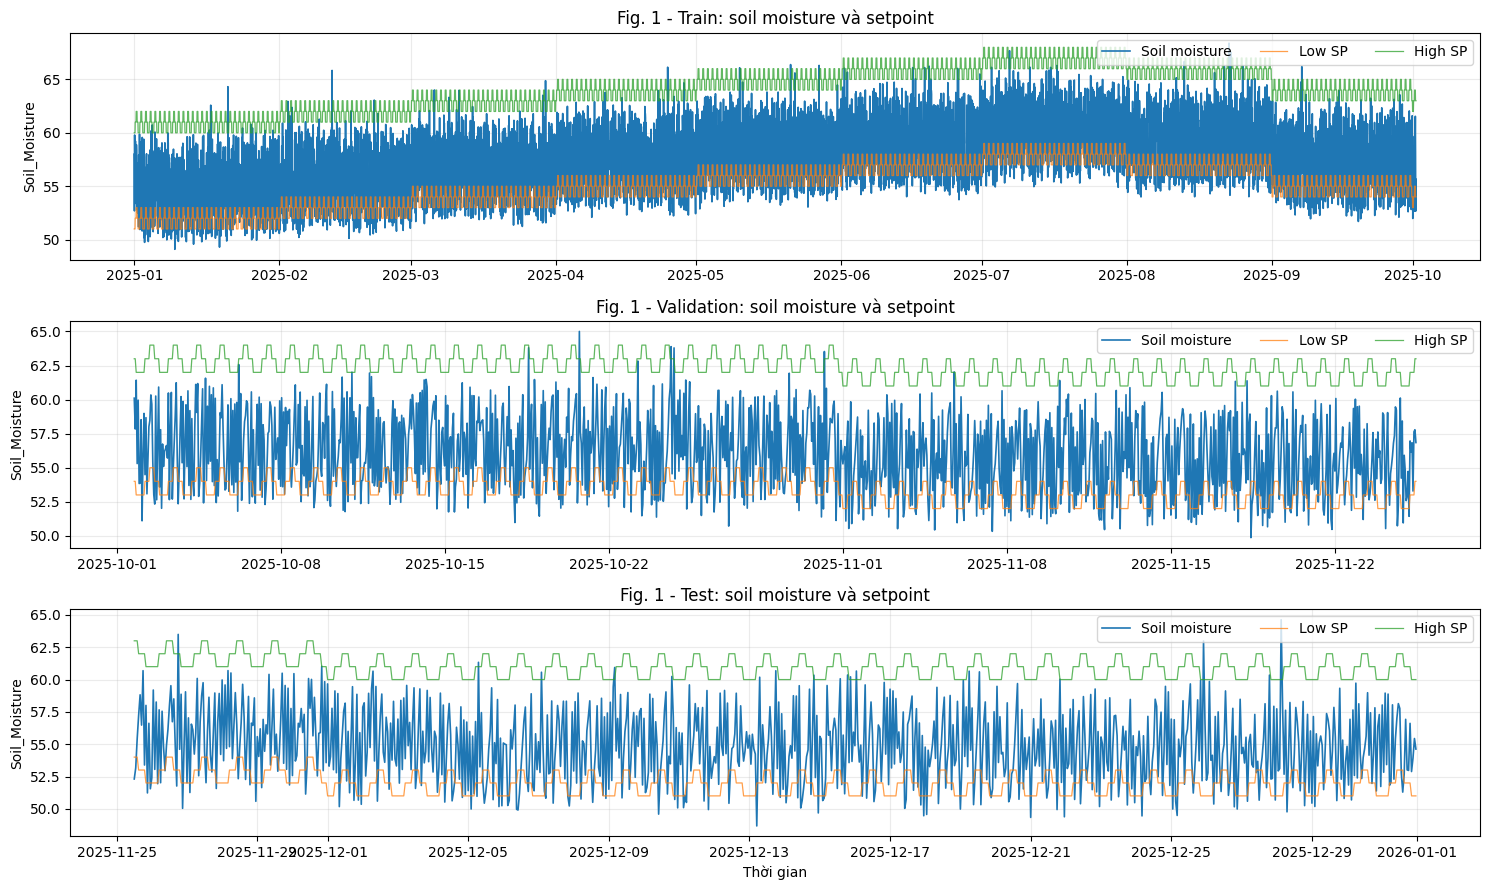

In [9]:
split_frames = [
    ("Train", df_train_raw),
    ("Validation", df_val_raw),
    ("Test", df_test_raw),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
for ax, (split_name, split_df) in zip(axes, split_frames):
    plot_df = split_df.iloc[::12].copy()
    ax.plot(plot_df["Timestamp"], plot_df["Soil_Moisture"], label="Soil moisture", linewidth=1.2)
    if {"Soil_Low_SP", "Soil_High_SP"}.issubset(plot_df.columns):
        ax.plot(plot_df["Timestamp"], plot_df["Soil_Low_SP"], label="Low SP", linewidth=0.9, alpha=0.75)
        ax.plot(plot_df["Timestamp"], plot_df["Soil_High_SP"], label="High SP", linewidth=0.9, alpha=0.75)
    ax.set_title(f"Fig. 1 - {split_name}: soil moisture và setpoint")
    ax.set_ylabel("Soil_Moisture")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", ncols=3)
axes[-1].set_xlabel("Thời gian")
fig.tight_layout()
plt.show()


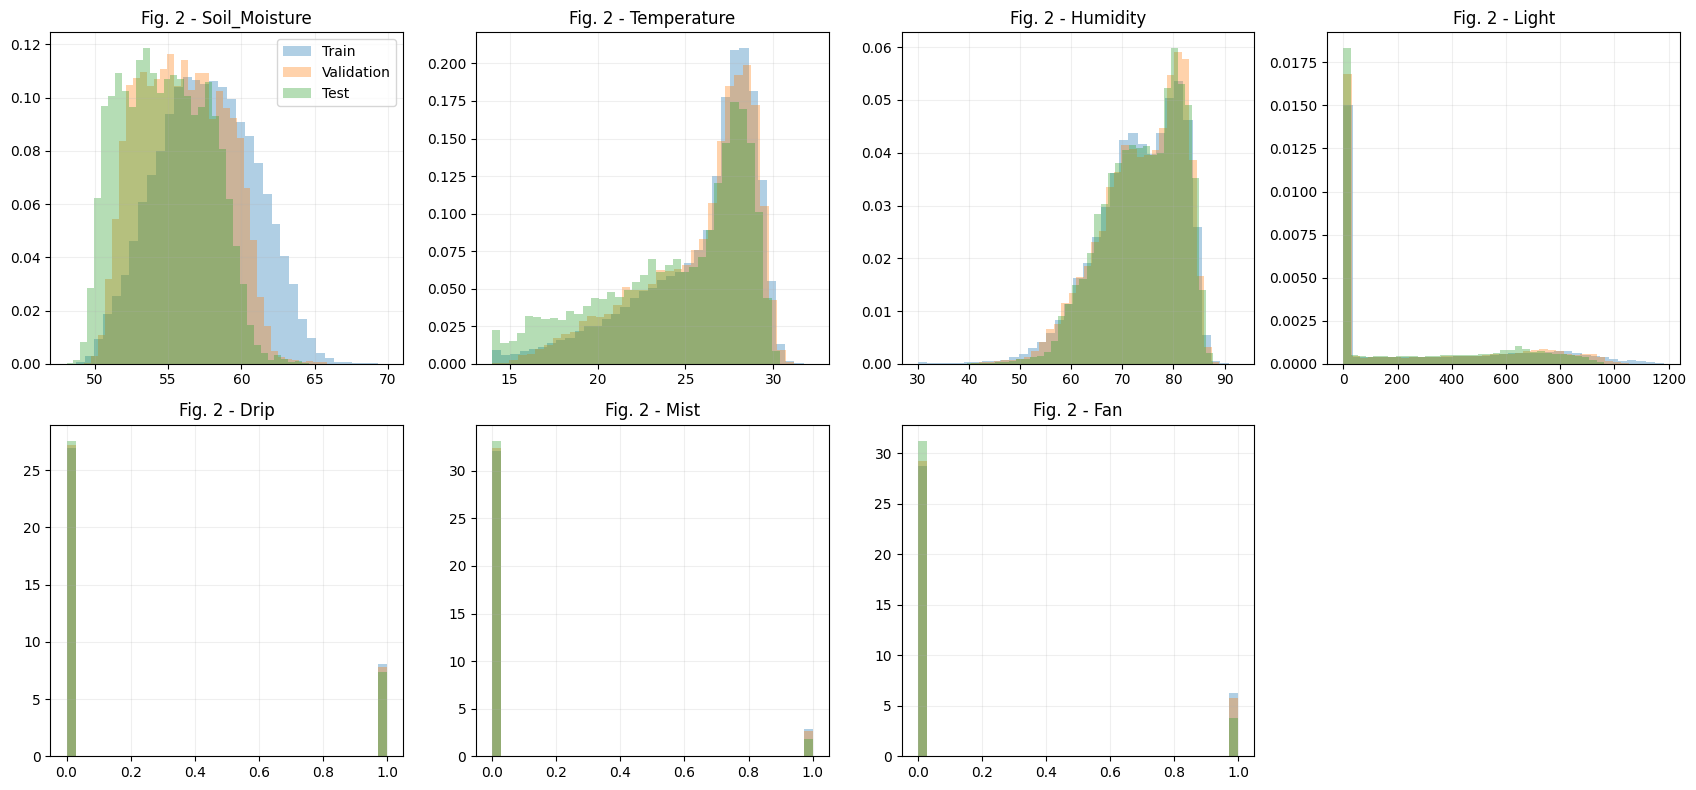

In [10]:
dist_cols = ["Soil_Moisture", "Temperature", "Humidity", "Light", "Drip", "Mist", "Fan"]
dist_df = pd.concat(
    [frame.assign(split=name) for name, frame in split_frames],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()
for ax, col in zip(axes, dist_cols):
    for split_name in ["Train", "Validation", "Test"]:
        values = dist_df.loc[dist_df["split"] == split_name, col].astype(float)
        ax.hist(values, bins=35, density=True, alpha=0.35, label=split_name)
    ax.set_title(f"Fig. 2 - {col}")
    ax.grid(True, alpha=0.2)
axes[len(dist_cols)].axis("off")
axes[0].legend()
fig.tight_layout()
plt.show()


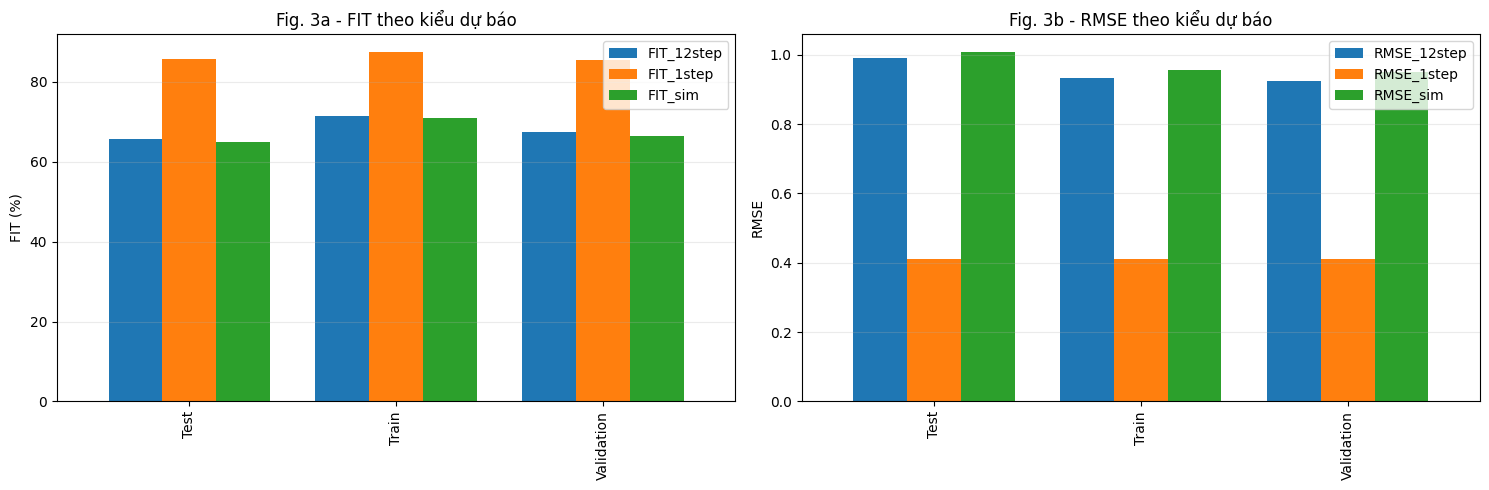

In [11]:
metrics_plot = metrics_df.melt(
    id_vars="split",
    value_vars=["FIT_1step", "FIT_12step", "FIT_sim", "RMSE_1step", "RMSE_12step", "RMSE_sim"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fit_plot = metrics_plot[metrics_plot["metric"].str.startswith("FIT")]
rmse_plot = metrics_plot[metrics_plot["metric"].str.startswith("RMSE")]

for ax, plot_data, title, ylabel in [
    (axes[0], fit_plot, "Fig. 3a - FIT theo kiểu dự báo", "FIT (%)"),
    (axes[1], rmse_plot, "Fig. 3b - RMSE theo kiểu dự báo", "RMSE"),
]:
    pivot = plot_data.pivot(index="split", columns="metric", values="value")
    pivot.plot(kind="bar", ax=ax, width=0.78)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="")
fig.tight_layout()
plt.show()


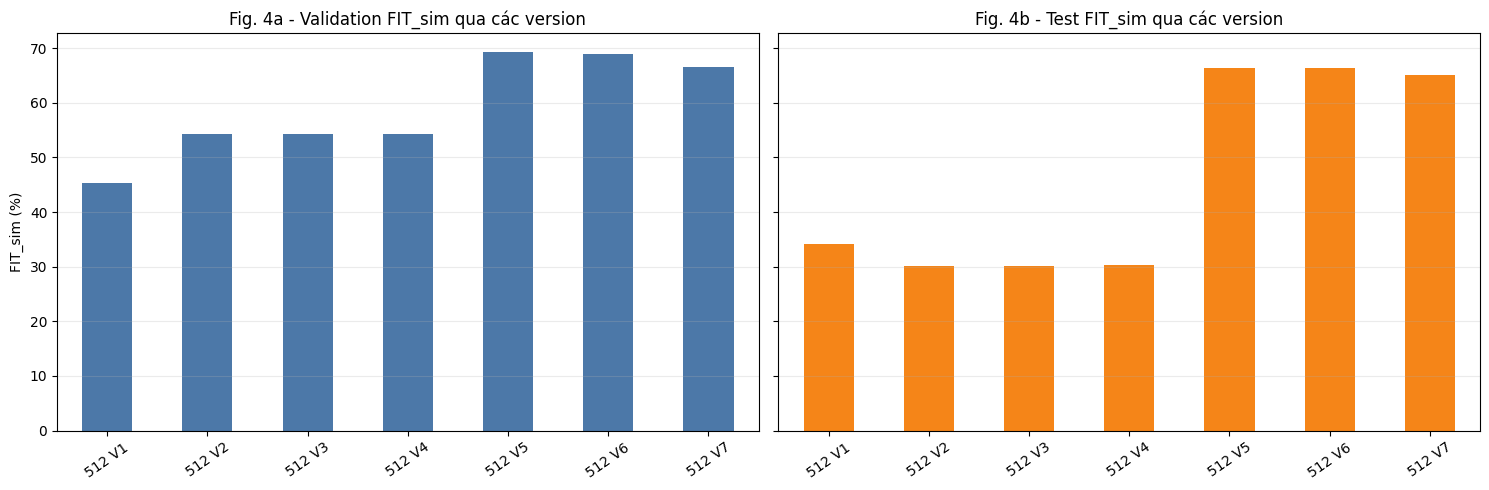

In [12]:
if not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    comparison_df.plot(x="version", y="val_FIT_sim", kind="bar", ax=axes[0], legend=False, color="#4c78a8")
    comparison_df.plot(x="version", y="test_FIT_sim", kind="bar", ax=axes[1], legend=False, color="#f58518")
    axes[0].set_title("Fig. 4a - Validation FIT_sim qua các version")
    axes[1].set_title("Fig. 4b - Test FIT_sim qua các version")
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("FIT_sim (%)")
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu comparison_df để vẽ Fig. 4.")


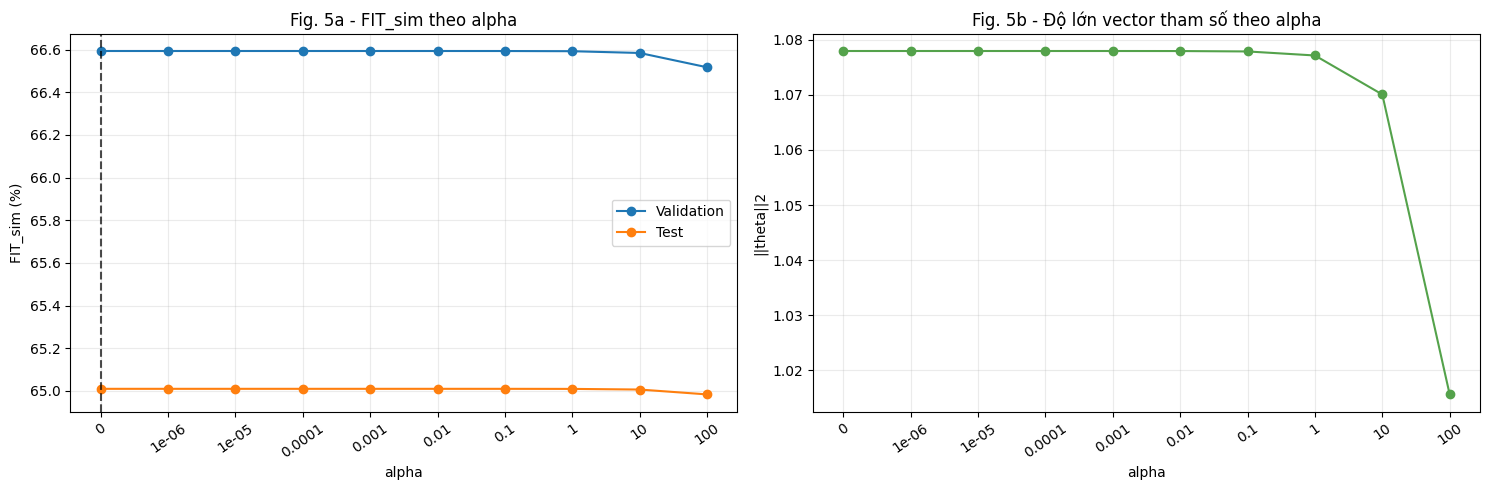

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
alpha_plot = alpha_search_df.copy()
alpha_plot["alpha_label"] = alpha_plot["alpha"].map(lambda x: f"{x:g}")
axes[0].plot(alpha_plot["alpha_label"], alpha_plot["val_FIT_sim"], marker="o", label="Validation")
axes[0].plot(alpha_plot["alpha_label"], alpha_plot["test_FIT_sim"], marker="o", label="Test")
axes[0].axvline(alpha_plot.index[alpha_plot["alpha"].eq(best_alpha)][0], color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Fig. 5a - FIT_sim theo alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("FIT_sim (%)")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(alpha_plot["alpha_label"], alpha_plot["theta_l2"], marker="o", color="#54a24b")
axes[1].set_title("Fig. 5b - Độ lớn vector tham số theo alpha")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("||theta||2")
axes[1].grid(True, alpha=0.25)
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()


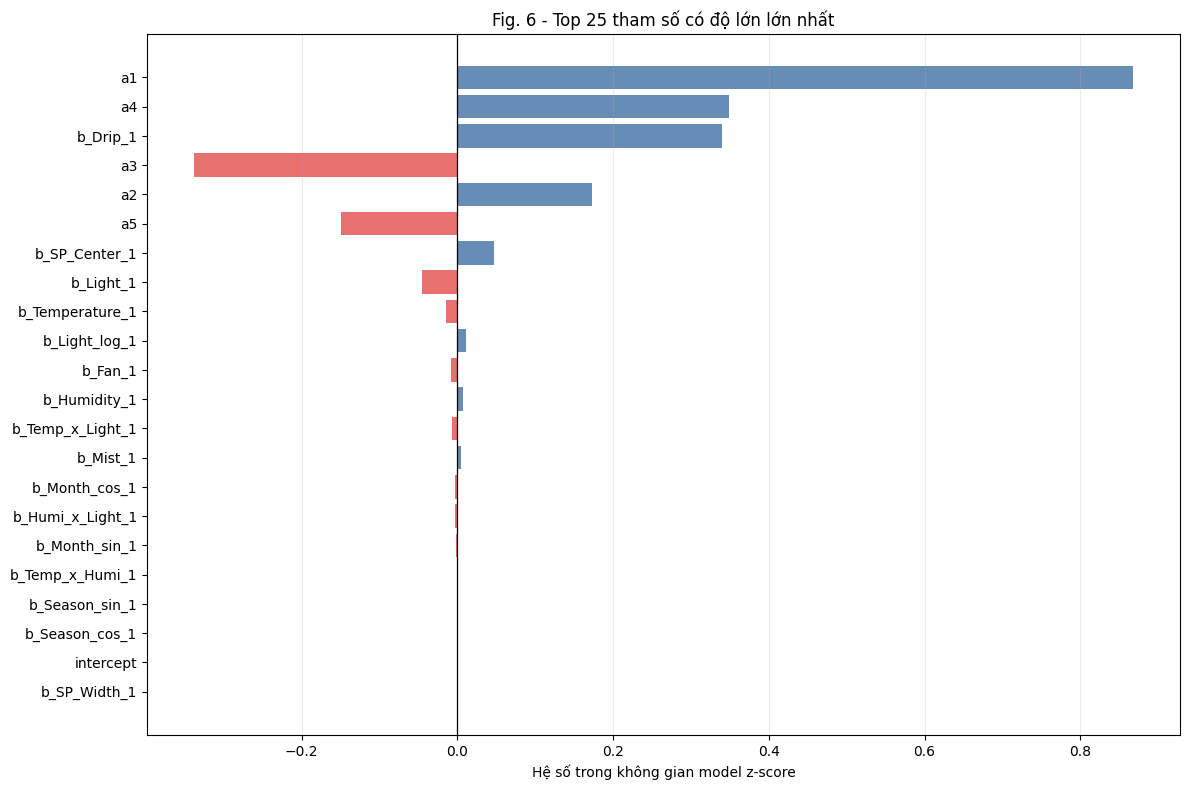

In [14]:
coef_df = best_summary_df.copy()
top_coef = coef_df.sort_values("abs_theta", ascending=False).head(25).sort_values("abs_theta")
colors = np.where(top_coef["theta"] >= 0, "#4c78a8", "#e45756")

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_coef["name"], top_coef["theta"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Fig. 6 - Top 25 tham số có độ lớn lớn nhất")
ax.set_xlabel("Hệ số trong không gian model" + (" z-score" if USE_ZSCORE else " raw"))
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


## 9. Free-run và dự báo


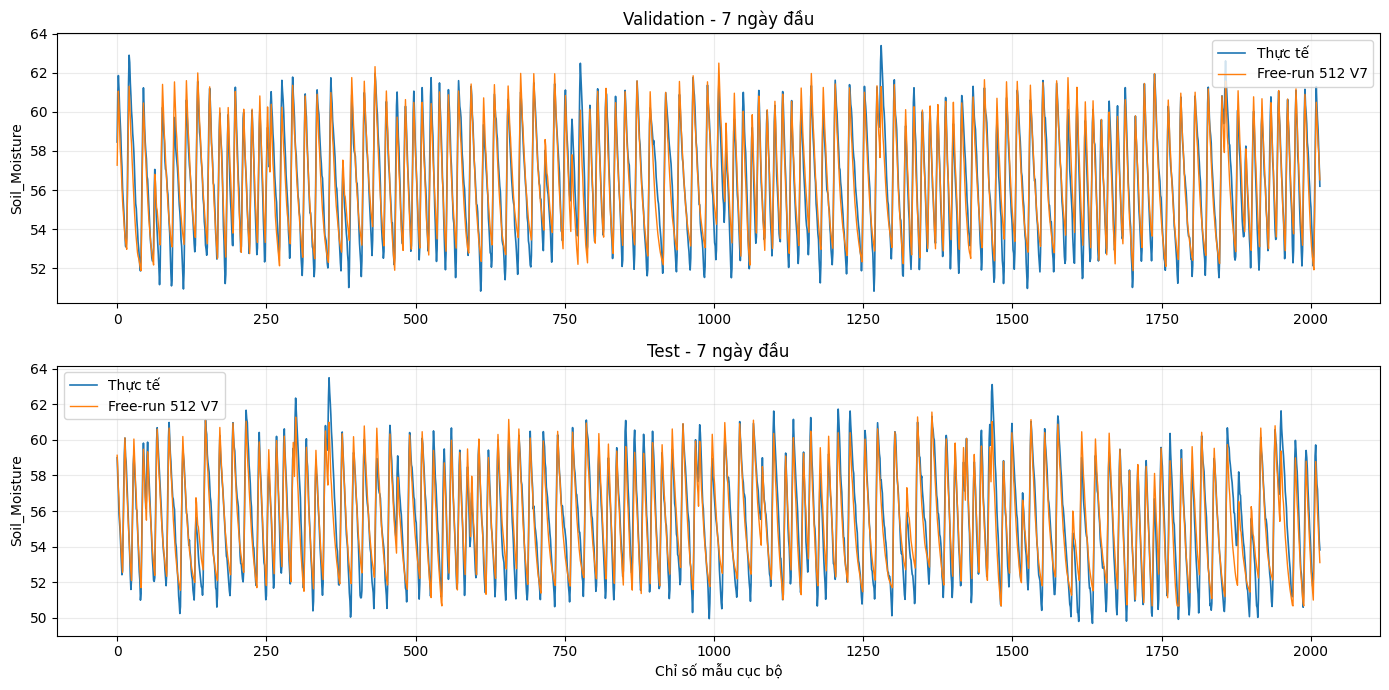

In [15]:
def prediction_frame_real(ev: dict, split_name: str) -> pd.DataFrame:
    arrays = ev["arrays"]
    n = len(arrays["y_true_sim"])
    return pd.DataFrame({
        "split": split_name,
        "idx": np.arange(n),
        "y_true": inverse_y(arrays["y_true_sim"]),
        "y_pred_sim": inverse_y(arrays["y_pred_sim"]),
        "y_pred_12step": inverse_y(arrays["y_pred_n_step"]),
    })


pred_train = prediction_frame_real(train_eval, "Train")
pred_val = prediction_frame_real(val_eval, "Validation")
pred_test = prediction_frame_real(test_eval, "Test")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, pred_df, title in [
    (axes[0], pred_val.iloc[: 7 * 24 * 12], "Validation - 7 ngày đầu"),
    (axes[1], pred_test.iloc[: 7 * 24 * 12], "Test - 7 ngày đầu"),
]:
    ax.plot(pred_df["idx"], pred_df["y_true"], label="Thực tế", linewidth=1.2)
    ax.plot(pred_df["idx"], pred_df["y_pred_sim"], label=f"Free-run 512 V{VERSION_NUMBER}", linewidth=1.0)
    ax.set_title(title)
    ax.set_ylabel("Soil_Moisture")
    ax.grid(True, alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Chỉ số mẫu cục bộ")
fig.tight_layout()
plt.show()


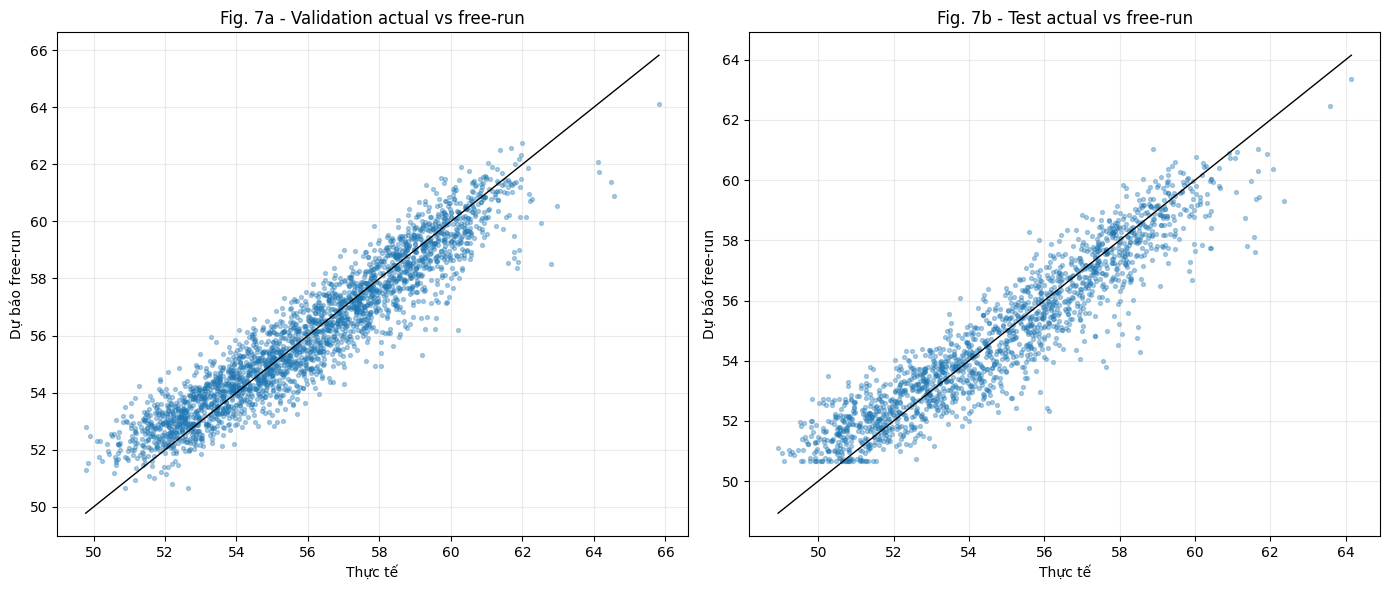

In [16]:
prediction_all = pd.concat([pred_train, pred_val, pred_test], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred_df, title in [
    (axes[0], pred_val, "Fig. 7a - Validation actual vs free-run"),
    (axes[1], pred_test, "Fig. 7b - Test actual vs free-run"),
]:
    sample_df = pred_df.iloc[::6].copy()
    ax.scatter(sample_df["y_true"], sample_df["y_pred_sim"], s=8, alpha=0.35)
    lo = min(sample_df["y_true"].min(), sample_df["y_pred_sim"].min())
    hi = max(sample_df["y_true"].max(), sample_df["y_pred_sim"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Thực tế")
    ax.set_ylabel("Dự báo free-run")
    ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


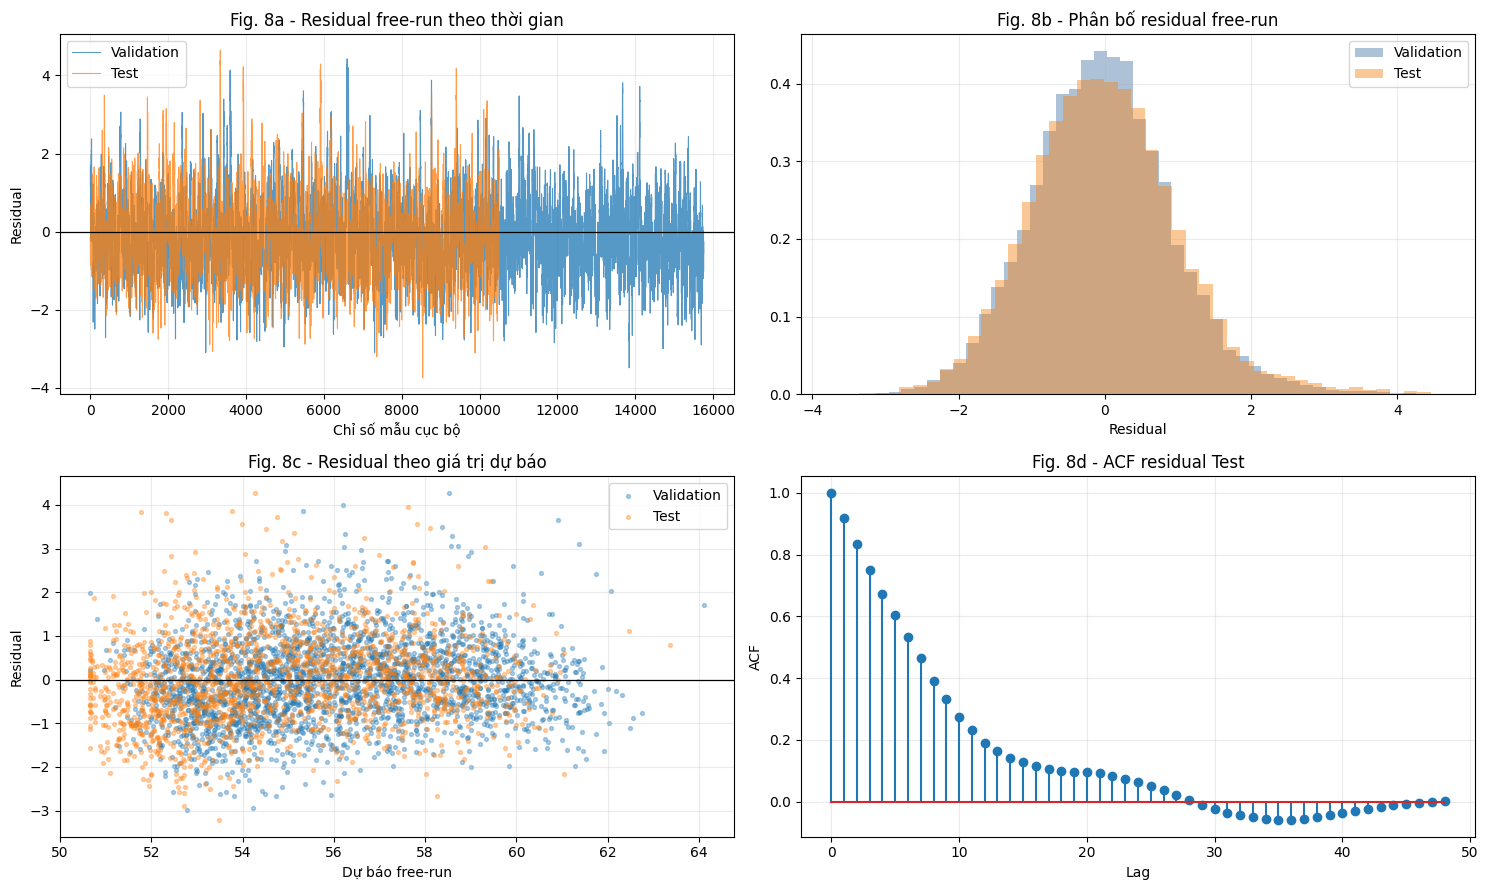

In [17]:
residual_frames = []
for pred_df in [pred_train, pred_val, pred_test]:
    tmp = pred_df.copy()
    tmp["residual_sim"] = tmp["y_true"] - tmp["y_pred_sim"]
    tmp["residual_12step"] = tmp["y_true"] - tmp["y_pred_12step"]
    residual_frames.append(tmp)
residual_df = pd.concat(residual_frames, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for split_name, color in [("Validation", "#4c78a8"), ("Test", "#f58518")]:
    tmp = residual_df[residual_df["split"] == split_name]
    axes[0, 0].plot(tmp["idx"], tmp["residual_sim"], linewidth=0.8, alpha=0.75, label=split_name)
    axes[0, 1].hist(tmp["residual_sim"], bins=45, alpha=0.45, density=True, label=split_name, color=color)
    axes[1, 0].scatter(tmp["y_pred_sim"].iloc[::6], tmp["residual_sim"].iloc[::6], s=8, alpha=0.35, label=split_name)

test_resid = residual_df[residual_df["split"] == "Test"]["residual_sim"].to_numpy(dtype=float)
max_lag = 48
acf = []
for lag in range(max_lag + 1):
    if lag == 0:
        acf.append(1.0)
    else:
        acf.append(float(np.corrcoef(test_resid[:-lag], test_resid[lag:])[0, 1]))

axes[0, 0].axhline(0, color="black", linewidth=0.9)
axes[0, 0].set_title("Fig. 8a - Residual free-run theo thời gian")
axes[0, 0].set_xlabel("Chỉ số mẫu cục bộ")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].legend()

axes[0, 1].set_title("Fig. 8b - Phân bố residual free-run")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].legend()

axes[1, 0].axhline(0, color="black", linewidth=0.9)
axes[1, 0].set_title("Fig. 8c - Residual theo giá trị dự báo")
axes[1, 0].set_xlabel("Dự báo free-run")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].grid(True, alpha=0.25)
axes[1, 0].legend()

axes[1, 1].stem(range(max_lag + 1), acf)
axes[1, 1].set_title("Fig. 8d - ACF residual Test")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("ACF")
axes[1, 1].grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


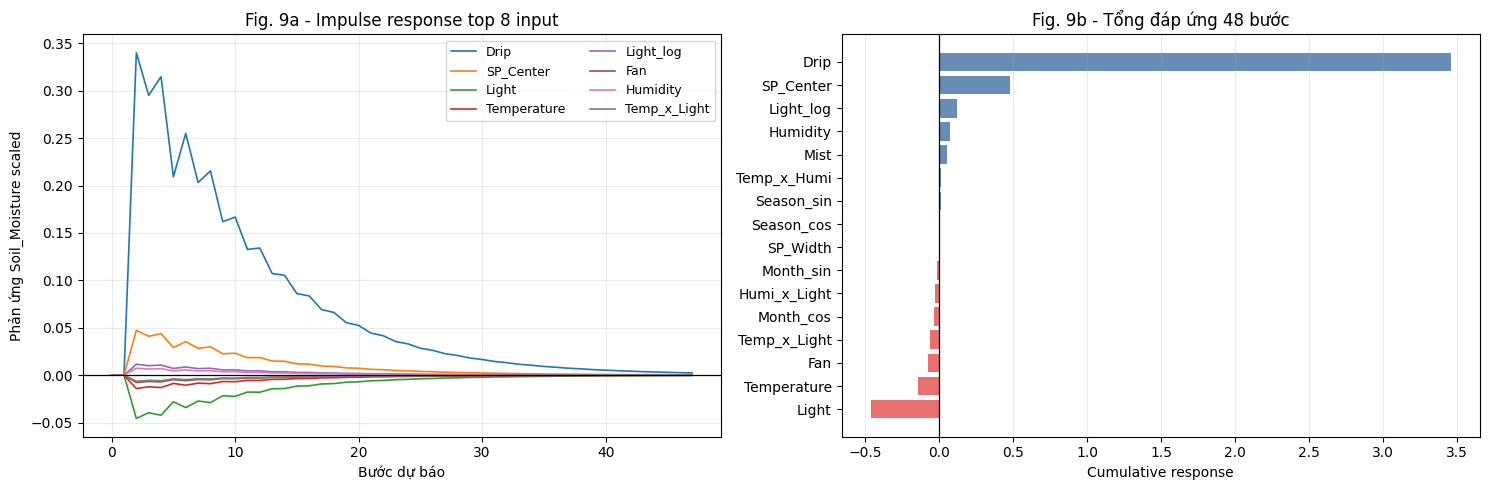

,input,cumulative_48,peak_abs
0,Drip,3.45697,0.34018
9,SP_Center,0.48021,0.04725
4,Light,-0.46402,0.04566
15,Temperature,-0.14380,0.01415
5,Light_log,0.11669,0.01148
1,Fan,-0.07852,0.00773
3,Humidity,0.07484,0.00736
14,Temp_x_Light,-0.06419,0.00632
6,Mist,0.05438,0.00535
7,Month_cos,-0.03292,0.00324


In [18]:
def impulse_response_df(theta: np.ndarray, config: ModelConfig, horizon: int = 48) -> pd.DataFrame:
    a = np.asarray(theta[: config.na], dtype=float)
    start = config.na
    rows = []
    for input_idx, input_name in enumerate(config.input_cols):
        b_start = start + input_idx * config.nb
        b = np.asarray(theta[b_start : b_start + config.nb], dtype=float)
        y = np.zeros(horizon, dtype=float)
        for t in range(horizon):
            ar_part = 0.0
            for lag in range(1, config.na + 1):
                if t - lag >= 0:
                    ar_part += a[lag - 1] * y[t - lag]
            input_part = 0.0
            for j in range(config.nb):
                lag = config.nk + j
                if t - lag == 0:
                    input_part += b[j]
            y[t] = ar_part + input_part
            rows.append({"input": input_name, "step": t, "response": y[t]})
    return pd.DataFrame(rows)


irf_df = impulse_response_df(theta_hat, MODEL_CONFIG, horizon=48)
irf_summary = (
    irf_df.groupby("input", as_index=False)
    .agg(cumulative_48=("response", "sum"), peak_abs=("response", lambda s: float(np.max(np.abs(s)))))
    .sort_values("peak_abs", ascending=False)
)
top_inputs = irf_summary.head(8)["input"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for input_name in top_inputs:
    tmp = irf_df[irf_df["input"] == input_name]
    axes[0].plot(tmp["step"], tmp["response"], linewidth=1.2, label=input_name)
axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].set_title("Fig. 9a - Impulse response top 8 input")
axes[0].set_xlabel("Bước dự báo")
axes[0].set_ylabel("Phản ứng Soil_Moisture" + (" scaled" if USE_ZSCORE else ""))
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncols=2, fontsize=9)

plot_irf = irf_summary.sort_values("cumulative_48")
colors = np.where(plot_irf["cumulative_48"] >= 0, "#4c78a8", "#e45756")
axes[1].barh(plot_irf["input"], plot_irf["cumulative_48"], color=colors, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.9)
axes[1].set_title("Fig. 9b - Tổng đáp ứng 48 bước")
axes[1].set_xlabel("Cumulative response")
axes[1].grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

irf_summary.round(5)


## 10. Bổ sung hình cho Chương 3

Các hình dưới đây bám theo checklist báo cáo Chương 3. Phần ARX và dataset là kết quả trực tiếp từ notebook. Phần Kalman là đánh giá offline trên tín hiệu soil moisture. Phần MPC/toàn hệ thống được trình bày dưới dạng proxy/khung đánh giá vì notebook ARX không chứa log MPC, log latency hoặc log WebSocket thật.

In [19]:

chapter3_coverage = pd.DataFrame([
    {"mục": "3.1 Mục tiêu thực nghiệm", "hình/bảng trong notebook": "Bảng câu hỏi thực nghiệm + metrics ARX", "trạng thái": "Đủ cho ARX"},
    {"mục": "3.2 Môi trường thực nghiệm", "hình/bảng trong notebook": "Bảng cấu hình dữ liệu/mô hình; thông tin phần cứng cần điền thủ công", "trạng thái": "Cần bổ sung mô tả hệ thật"},
    {"mục": "3.4 Dataset thực nghiệm", "hình/bảng trong notebook": "Fig. 10 thống kê dataset, split, missing data", "trạng thái": "Đủ nếu dùng dữ liệu hiện tại"},
    {"mục": "3.6 Đánh giá ARX", "hình/bảng trong notebook": "Fig. 3, 6, 7, 8, 9, 11, 12", "trạng thái": "Đủ"},
    {"mục": "3.7 Đánh giá Kalman Filter", "hình/bảng trong notebook": "Fig. 13 offline KF/AKF proxy", "trạng thái": "Có hình offline; cần log thật nếu triển khai"},
    {"mục": "3.8 Đánh giá MPC", "hình/bảng trong notebook": "Fig. 14 setpoint/control proxy từ dữ liệu", "trạng thái": "Chưa phải MPC thật"},
    {"mục": "3.9 Đánh giá toàn hệ thống", "hình/bảng trong notebook": "Fig. 15 checklist log cần đo", "trạng thái": "Cần log runtime"},
    {"mục": "3.10 Hạn chế", "hình/bảng trong notebook": "Bảng hạn chế-nguyên nhân-ảnh hưởng-khắc phục", "trạng thái": "Đủ khung viết báo cáo"},
])
chapter3_coverage


,mục,hình/bảng trong notebook,trạng thái
0,3.1 Mục tiêu thực nghiệm,Bảng câu hỏi thực nghiệm + metrics ARX,Đủ cho ARX
1,3.2 Môi trường thực nghiệm,Bảng cấu hình dữ liệu/mô hình; thông tin phần ...,Cần bổ sung mô tả hệ thật
2,3.4 Dataset thực nghiệm,"Fig. 10 thống kê dataset, split, missing data",Đủ nếu dùng dữ liệu hiện tại
3,3.6 Đánh giá ARX,"Fig. 3, 6, 7, 8, 9, 11, 12",Đủ
4,3.7 Đánh giá Kalman Filter,Fig. 13 offline KF/AKF proxy,Có hình offline; cần log thật nếu triển khai
5,3.8 Đánh giá MPC,Fig. 14 setpoint/control proxy từ dữ liệu,Chưa phải MPC thật
6,3.9 Đánh giá toàn hệ thống,Fig. 15 checklist log cần đo,Cần log runtime
7,3.10 Hạn chế,Bảng hạn chế-nguyên nhân-ảnh hưởng-khắc phục,Đủ khung viết báo cáo


In [20]:

report_questions = pd.DataFrame([
    {"câu hỏi thực nghiệm": "ARX(5,1,2) đạt RMSE/FIT bao nhiêu trên test?", "nguồn trả lời": "metrics_df + Fig. 3/Fig. 7/Fig. 8", "kết quả chính": f"FIT_sim test = {metrics_df.loc[metrics_df['split'].eq('Test'), 'FIT_sim'].iloc[0]:.2f}%, RMSE_sim test = {metrics_df.loc[metrics_df['split'].eq('Test'), 'RMSE_sim'].iloc[0]:.3f}"},
    {"câu hỏi thực nghiệm": "ARX có tốt hơn naive baseline không?", "nguồn trả lời": "Fig. 11", "kết quả chính": "So sánh với dự báo giữ nguyên giá trị trước đó"},
    {"câu hỏi thực nghiệm": "Mô hình dự đoán kém trong tình huống nào?", "nguồn trả lời": "Fig. 12 + residual diagnostics", "kết quả chính": "Kiểm tra quanh các thời điểm bật tưới"},
    {"câu hỏi thực nghiệm": "Kalman giảm nhiễu bao nhiêu?", "nguồn trả lời": "Fig. 13", "kết quả chính": "Đánh giá offline bằng variance của sai phân/innovation"},
    {"câu hỏi thực nghiệm": "MPC giữ ẩm trong dải setpoint ra sao?", "nguồn trả lời": "Fig. 14", "kết quả chính": "Notebook chỉ có proxy từ dữ liệu/control log hiện có, chưa có MPC log thật"},
])
report_questions


,câu hỏi thực nghiệm,nguồn trả lời,kết quả chính
0,"ARX(5,1,2) đạt RMSE/FIT bao nhiêu trên test?",metrics_df + Fig. 3/Fig. 7/Fig. 8,"FIT_sim test = 65.01%, RMSE_sim test = 1.009"
1,ARX có tốt hơn naive baseline không?,Fig. 11,So sánh với dự báo giữ nguyên giá trị trước đó
2,Mô hình dự đoán kém trong tình huống nào?,Fig. 12 + residual diagnostics,Kiểm tra quanh các thời điểm bật tưới
3,Kalman giảm nhiễu bao nhiêu?,Fig. 13,Đánh giá offline bằng variance của sai phân/in...
4,MPC giữ ẩm trong dải setpoint ra sao?,Fig. 14,Notebook chỉ có proxy từ dữ liệu/control log h...


### 10.1 Dataset figures tách riêng

Các bảng dataset/missing được vẽ thành từng hình riêng để dễ chụp và đưa vào báo cáo. Mỗi hình cũng được lưu ra thư mục `figures_dataset/`.

In [21]:

from pathlib import Path

FIG_DIR = VERSION_DIR / "figures_dataset" / VERSION_NAME
FIG_DIR.mkdir(exist_ok=True)


def render_table_figure(table_df: pd.DataFrame, title: str, filename: str, figsize=(12, 4.5), fontsize: int = 9):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1.0, 1.35)
    ax.set_title(title, pad=14, fontsize=13)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


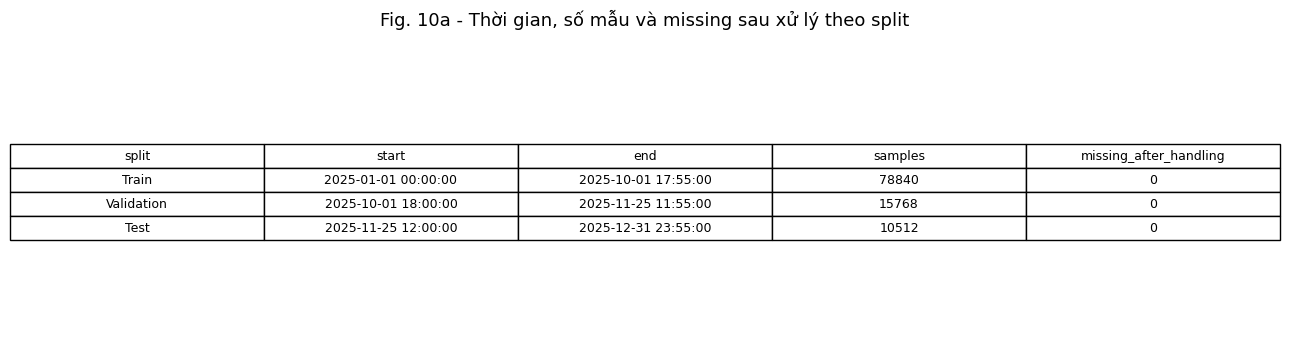

Saved: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_Model_Version 512\figures_dataset\v7_512_missing_augmented_zscore_intercept_ridge_clip\fig10a_split_samples_missing.png


,split,start,end,samples,missing_after_handling
0,Train,2025-01-01 00:00:00,2025-10-01 17:55:00,78840,0
1,Validation,2025-10-01 18:00:00,2025-11-25 11:55:00,15768,0
2,Test,2025-11-25 12:00:00,2025-12-31 23:55:00,10512,0


In [22]:

stat_cols = ["Soil_Moisture", "Temperature", "Humidity", "Light", "Drip", "Mist", "Fan"]
collection_rows = []
for split_name, split_df in split_frames:
    collection_rows.append({
        "split": split_name,
        "start": str(split_df["Timestamp"].min()),
        "end": str(split_df["Timestamp"].max()),
        "samples": len(split_df),
        "missing_after_handling": int(split_df[stat_cols].isna().sum().sum()),
    })
collection_df = pd.DataFrame(collection_rows)

render_table_figure(
    collection_df,
    "Fig. 10a - Thời gian, số mẫu và missing sau xử lý theo split",
    "fig10a_split_samples_missing.png",
    figsize=(13, 3.6),
    fontsize=9,
)
collection_df


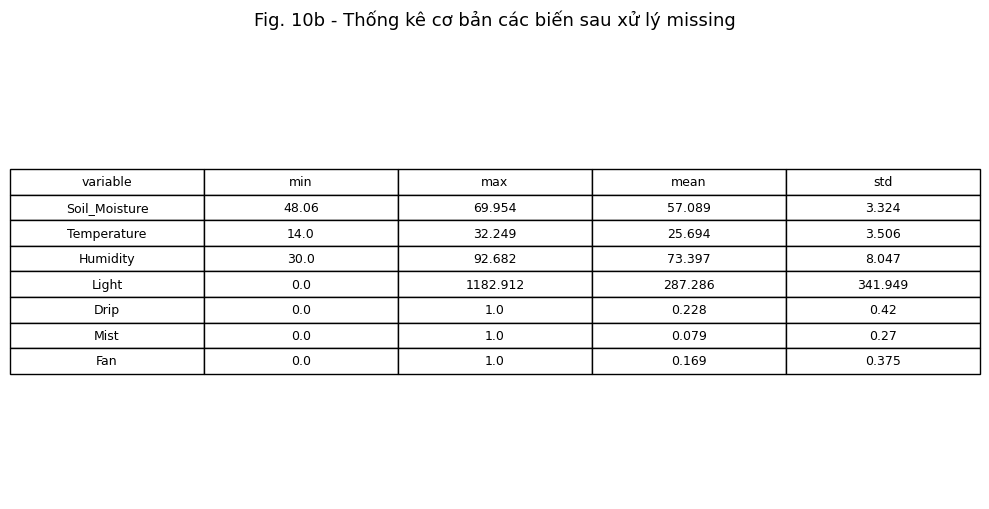

Saved: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_Model_Version 512\figures_dataset\v7_512_missing_augmented_zscore_intercept_ridge_clip\fig10b_basic_statistics.png


,variable,min,max,mean,std
0,Soil_Moisture,48.06,69.954,57.089,3.324
1,Temperature,14.00,32.249,25.694,3.506
2,Humidity,30.00,92.682,73.397,8.047
3,Light,0.00,1182.912,287.286,341.949
4,Drip,0.00,1.000,0.228,0.420
5,Mist,0.00,1.000,0.079,0.270
6,Fan,0.00,1.000,0.169,0.375


In [23]:

stats_df = (
    df_full[stat_cols]
    .agg(["min", "max", "mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
    .round(3)
)

render_table_figure(
    stats_df,
    "Fig. 10b - Thống kê cơ bản các biến sau xử lý missing",
    "fig10b_basic_statistics.png",
    figsize=(10, 5.2),
    fontsize=9,
)
stats_df


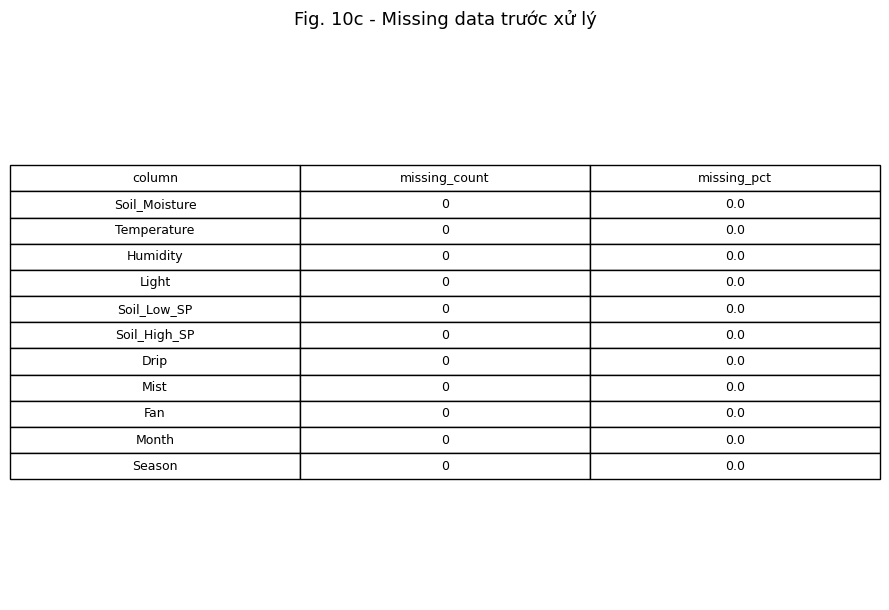

Saved: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_Model_Version 512\figures_dataset\v7_512_missing_augmented_zscore_intercept_ridge_clip\fig10c_missing_before.png


,column,missing_count,missing_pct
0,Soil_Moisture,0,0.0
1,Temperature,0,0.0
2,Humidity,0,0.0
3,Light,0,0.0
4,Soil_Low_SP,0,0.0
5,Soil_High_SP,0,0.0
6,Drip,0,0.0
7,Mist,0,0.0
8,Fan,0,0.0
9,Month,0,0.0


In [24]:

missing_before_df = (
    missing_summary[missing_summary["stage"].eq("before_handling")]
    [["column", "missing_count", "missing_pct"]]
    .copy()
)
missing_before_df["missing_pct"] = missing_before_df["missing_pct"].round(4)

render_table_figure(
    missing_before_df,
    "Fig. 10c - Missing data trước xử lý",
    "fig10c_missing_before.png",
    figsize=(9, 6.2),
    fontsize=9,
)
missing_before_df


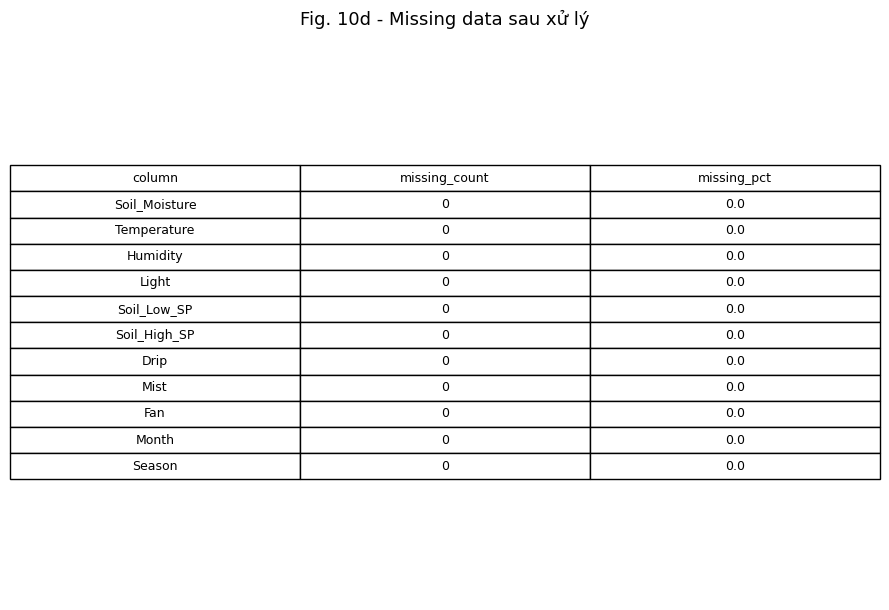

Saved: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_Model_Version 512\figures_dataset\v7_512_missing_augmented_zscore_intercept_ridge_clip\fig10d_missing_after.png


,column,missing_count,missing_pct
11,Soil_Moisture,0,0.0
12,Temperature,0,0.0
13,Humidity,0,0.0
14,Light,0,0.0
15,Soil_Low_SP,0,0.0
16,Soil_High_SP,0,0.0
17,Drip,0,0.0
18,Mist,0,0.0
19,Fan,0,0.0
20,Month,0,0.0


In [25]:

missing_after_df = (
    missing_summary[missing_summary["stage"].eq("after_handling")]
    [["column", "missing_count", "missing_pct"]]
    .copy()
)
missing_after_df["missing_pct"] = missing_after_df["missing_pct"].round(4)

render_table_figure(
    missing_after_df,
    "Fig. 10d - Missing data sau xử lý",
    "fig10d_missing_after.png",
    figsize=(9, 6.2),
    fontsize=9,
)
missing_after_df


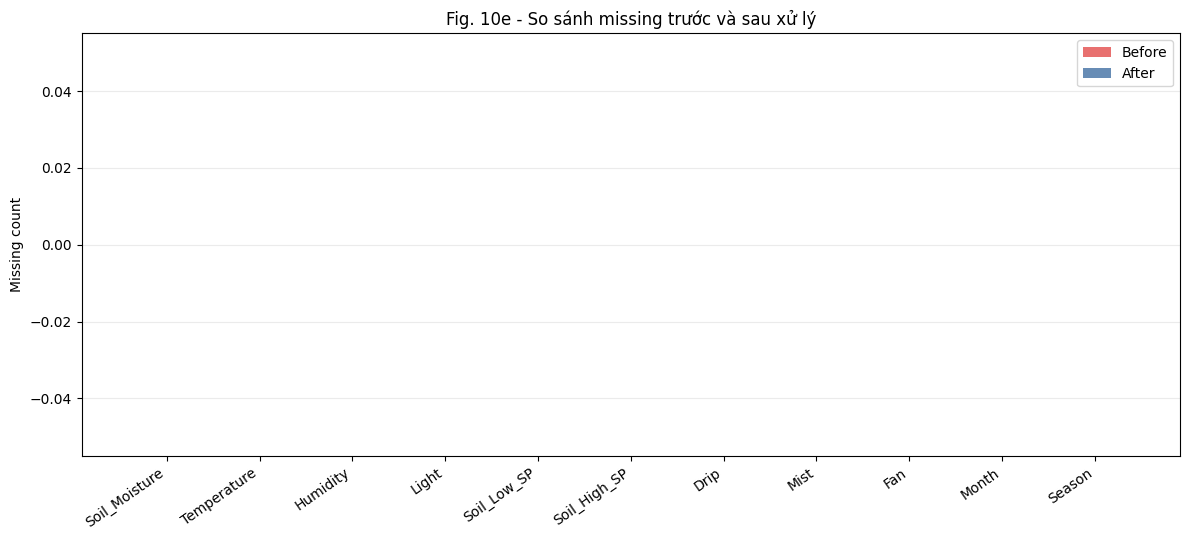

Saved: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_Model_Version 512\figures_dataset\v7_512_missing_augmented_zscore_intercept_ridge_clip\fig10e_missing_before_after_bar.png


,column,missing_count_before,missing_pct_before,missing_count_after,missing_pct_after
0,Soil_Moisture,0,0.0,0,0.0
1,Temperature,0,0.0,0,0.0
2,Humidity,0,0.0,0,0.0
3,Light,0,0.0,0,0.0
4,Soil_Low_SP,0,0.0,0,0.0
5,Soil_High_SP,0,0.0,0,0.0
6,Drip,0,0.0,0,0.0
7,Mist,0,0.0,0,0.0
8,Fan,0,0.0,0,0.0
9,Month,0,0.0,0,0.0


In [26]:

missing_compare_df = missing_before_df.merge(
    missing_after_df,
    on="column",
    suffixes=("_before", "_after"),
)

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(missing_compare_df))
width = 0.38
ax.bar(x - width / 2, missing_compare_df["missing_count_before"], width, label="Before", color="#e45756", alpha=0.85)
ax.bar(x + width / 2, missing_compare_df["missing_count_after"], width, label="After", color="#4c78a8", alpha=0.85)
ax.set_title("Fig. 10e - So sánh missing trước và sau xử lý")
ax.set_ylabel("Missing count")
ax.set_xticks(x)
ax.set_xticklabels(missing_compare_df["column"], rotation=35, ha="right")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
out = FIG_DIR / "fig10e_missing_before_after_bar.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", out)
missing_compare_df


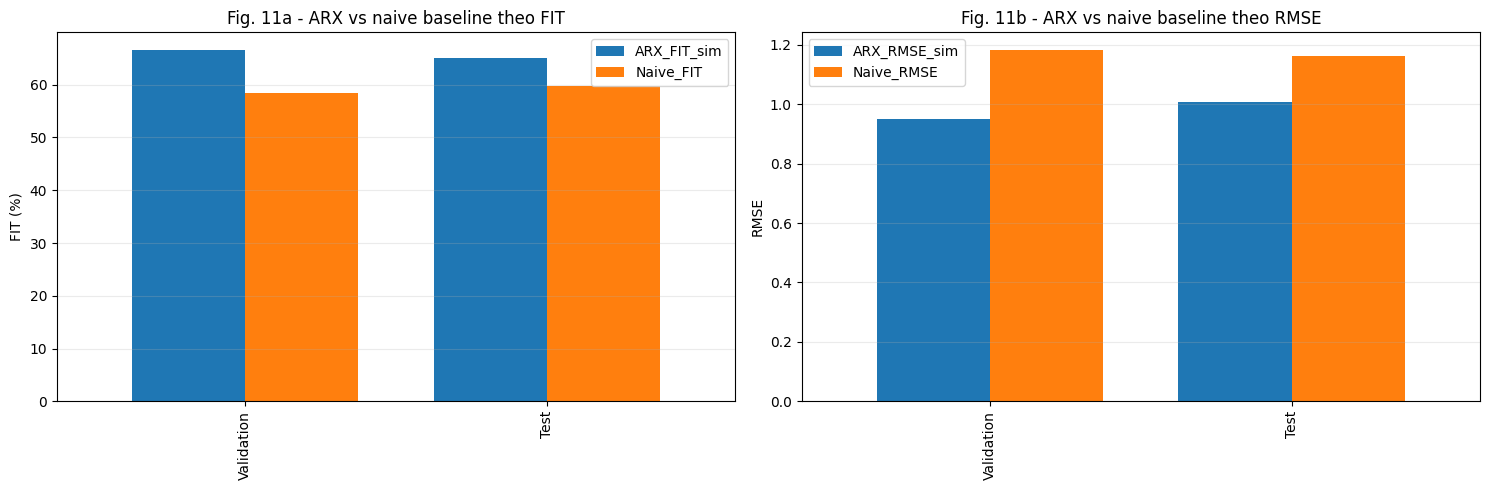

,split,ARX_FIT_sim,Naive_FIT,ARX_RMSE_sim,Naive_RMSE,RMSE_reduction_pct
0,Validation,66.5931,58.4670,0.9510,1.1823,19.5653
1,Test,65.0094,59.6949,1.0086,1.1618,13.1856


In [27]:

def naive_previous_metrics(pred_df: pd.DataFrame, split_name: str) -> dict:
    y_true = pred_df["y_true"].to_numpy(dtype=float)
    y_naive = np.r_[y_true[0], y_true[:-1]]
    arx_metrics = compute_metrics(y_true, pred_df["y_pred_sim"].to_numpy(dtype=float), n_params=len(theta_hat))
    naive_metrics = compute_metrics(y_true, y_naive, n_params=1)
    return {
        "split": split_name,
        "ARX_FIT_sim": arx_metrics["FIT"],
        "Naive_FIT": naive_metrics["FIT"],
        "ARX_RMSE_sim": arx_metrics["RMSE"],
        "Naive_RMSE": naive_metrics["RMSE"],
        "RMSE_reduction_pct": 100.0 * (naive_metrics["RMSE"] - arx_metrics["RMSE"]) / max(naive_metrics["RMSE"], 1e-12),
    }

naive_compare_df = pd.DataFrame([
    naive_previous_metrics(pred_val, "Validation"),
    naive_previous_metrics(pred_test, "Test"),
]).round(4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
naive_compare_df.plot(x="split", y=["ARX_FIT_sim", "Naive_FIT"], kind="bar", ax=axes[0], width=0.75)
axes[0].set_title("Fig. 11a - ARX vs naive baseline theo FIT")
axes[0].set_xlabel("")
axes[0].set_ylabel("FIT (%)")
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].legend(title="")
naive_compare_df.plot(x="split", y=["ARX_RMSE_sim", "Naive_RMSE"], kind="bar", ax=axes[1], width=0.75)
axes[1].set_title("Fig. 11b - ARX vs naive baseline theo RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(title="")
fig.tight_layout()
plt.show()
naive_compare_df


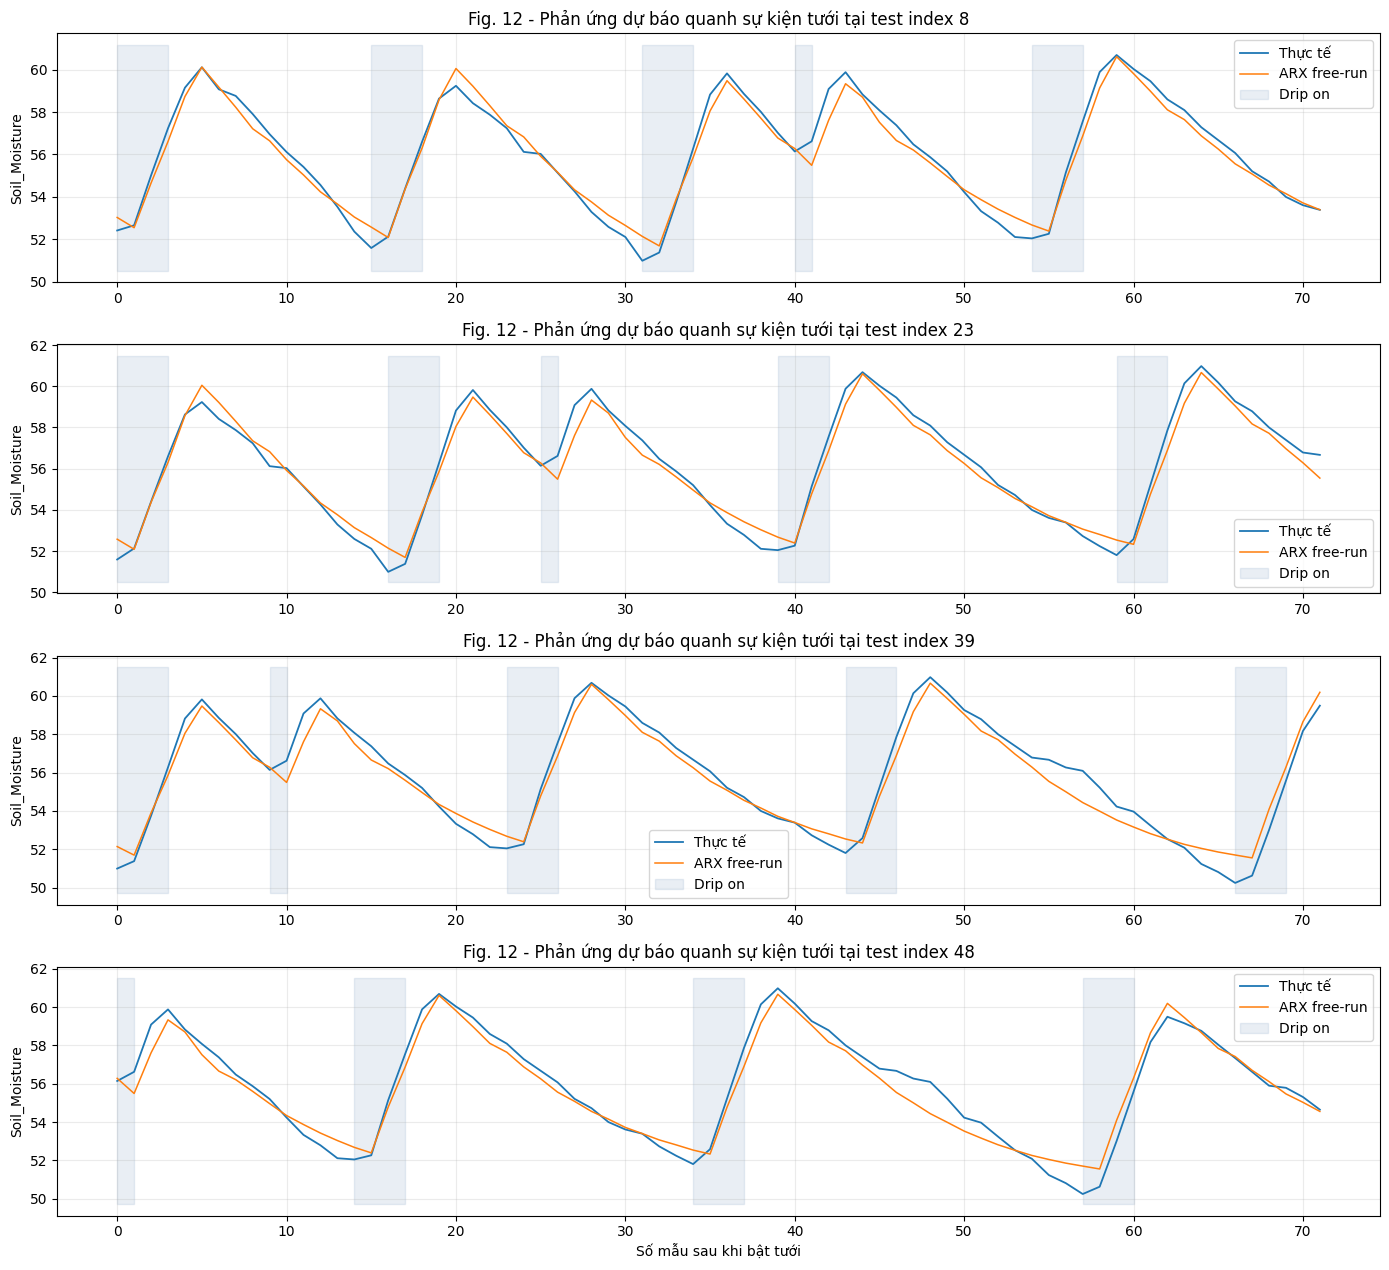

In [28]:

max_lag = max(MODEL_CONFIG.na, MODEL_CONFIG.nb + MODEL_CONFIG.nk - 1)
test_control_aligned = df_test_raw.iloc[max_lag:].reset_index(drop=True).copy()
window = 72
onsets = np.flatnonzero((test_control_aligned["Drip"].astype(float).diff().fillna(0) > 0).to_numpy())
selected_onsets = [idx for idx in onsets if idx + window < len(pred_test)][:4]

if selected_onsets:
    fig, axes = plt.subplots(len(selected_onsets), 1, figsize=(14, 3.2 * len(selected_onsets)), sharex=False)
    if len(selected_onsets) == 1:
        axes = [axes]
    for ax, start_idx in zip(axes, selected_onsets):
        sl = slice(start_idx, start_idx + window)
        local = pred_test.iloc[sl].copy()
        ctrl = test_control_aligned.iloc[sl].copy()
        t = np.arange(len(local))
        ax.plot(t, local["y_true"], label="Thực tế", linewidth=1.3)
        ax.plot(t, local["y_pred_sim"], label="ARX free-run", linewidth=1.1)
        drip_line = ctrl["Drip"].to_numpy(dtype=float)
        if drip_line.max() > 0:
            y_min, y_max = ax.get_ylim()
            ax.fill_between(t, y_min, y_max, where=drip_line > 0, alpha=0.12, color="#4c78a8", label="Drip on")
        ax.set_title(f"Fig. 12 - Phản ứng dự báo quanh sự kiện tưới tại test index {start_idx}")
        ax.set_ylabel("Soil_Moisture")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")
    axes[-1].set_xlabel("Số mẫu sau khi bật tưới")
    fig.tight_layout()
    plt.show()
else:
    print("Không tìm thấy đủ sự kiện Drip bật trong tập test để vẽ Fig. 12.")


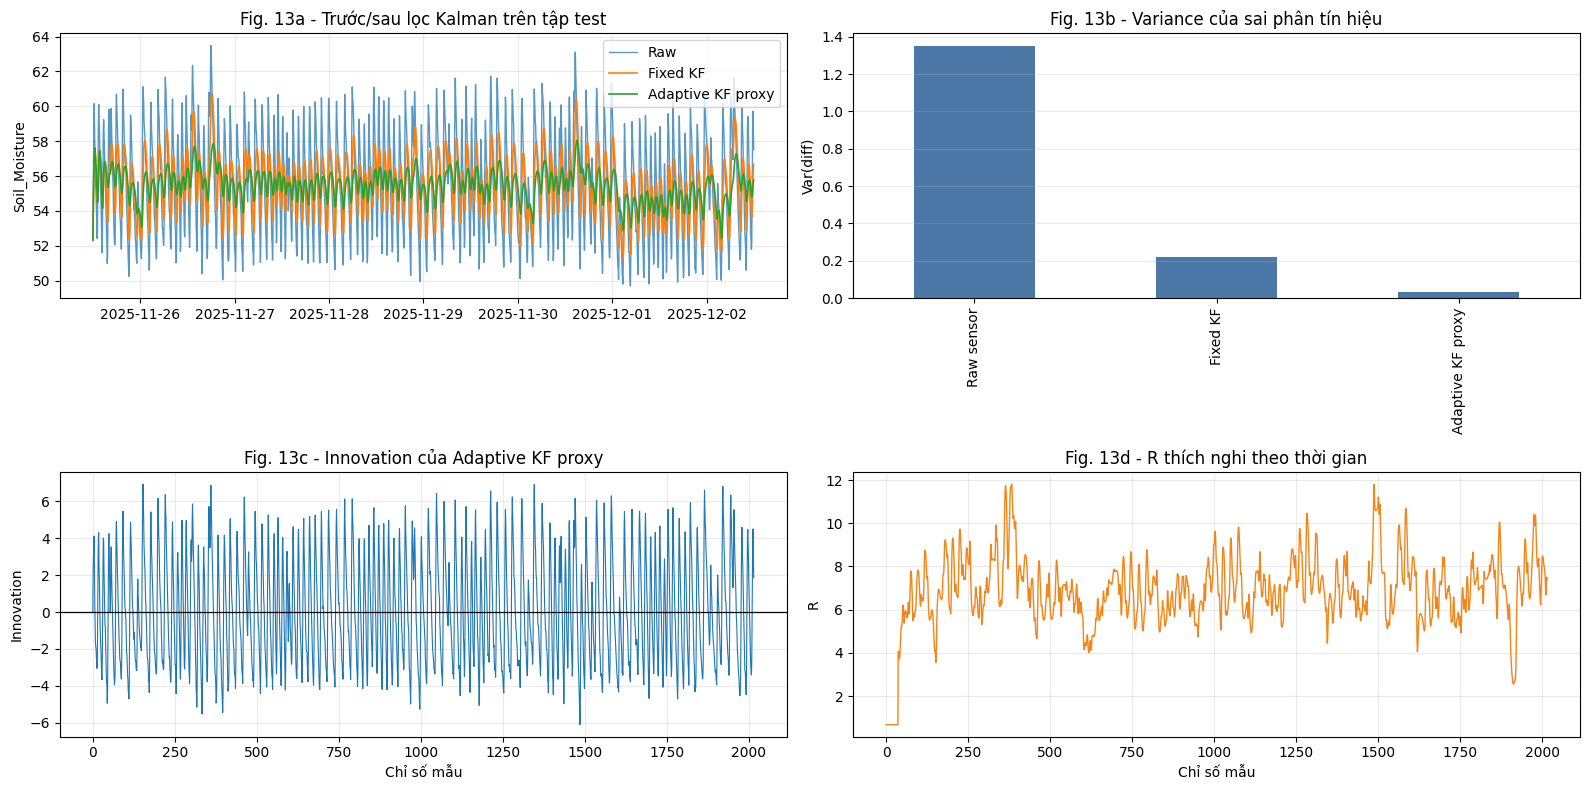

,signal,diff_variance,noise_reduction_pct
0,Raw sensor,1.3509,0.0000
1,Fixed KF,0.2224,83.5394
2,Adaptive KF proxy,0.0319,97.6421


In [29]:

def kalman_1d(z: np.ndarray, q: float, r0: float, adaptive: bool = False, window: int = 36):
    x = np.zeros_like(z, dtype=float)
    p = np.zeros_like(z, dtype=float)
    r_series = np.zeros_like(z, dtype=float)
    x[0] = z[0]
    p[0] = 1.0
    r_series[0] = r0
    innovations = np.zeros_like(z, dtype=float)
    for i in range(1, len(z)):
        x_pred = x[i - 1]
        p_pred = p[i - 1] + q
        if adaptive and i > window:
            local_var = float(np.var(z[i-window:i] - x[i-window:i]))
            r = max(local_var, 1e-6)
        else:
            r = r0
        innovations[i] = z[i] - x_pred
        k = p_pred / (p_pred + r)
        x[i] = x_pred + k * innovations[i]
        p[i] = (1.0 - k) * p_pred
        r_series[i] = r
    return x, innovations, r_series

kf_df = df_test_raw[["Timestamp", "Soil_Moisture"]].copy().reset_index(drop=True)
z = kf_df["Soil_Moisture"].astype(float).to_numpy()
q = max(float(np.var(np.diff(z))) * 0.02, 1e-6)
r0 = max(float(np.var(np.diff(z))) * 0.5, 1e-6)
kf_fixed, innov_fixed, r_fixed = kalman_1d(z, q=q, r0=r0, adaptive=False)
kf_adapt, innov_adapt, r_adapt = kalman_1d(z, q=q, r0=r0, adaptive=True)
noise_raw = float(np.var(np.diff(z)))
noise_fixed = float(np.var(np.diff(kf_fixed)))
noise_adapt = float(np.var(np.diff(kf_adapt)))
kalman_summary = pd.DataFrame([
    {"signal": "Raw sensor", "diff_variance": noise_raw, "noise_reduction_pct": 0.0},
    {"signal": "Fixed KF", "diff_variance": noise_fixed, "noise_reduction_pct": 100.0 * (noise_raw - noise_fixed) / max(noise_raw, 1e-12)},
    {"signal": "Adaptive KF proxy", "diff_variance": noise_adapt, "noise_reduction_pct": 100.0 * (noise_raw - noise_adapt) / max(noise_raw, 1e-12)},
]).round(4)

plot_n = min(7 * 24 * 12, len(kf_df))
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes[0, 0].plot(kf_df["Timestamp"].iloc[:plot_n], z[:plot_n], label="Raw", linewidth=1.0, alpha=0.75)
axes[0, 0].plot(kf_df["Timestamp"].iloc[:plot_n], kf_fixed[:plot_n], label="Fixed KF", linewidth=1.2)
axes[0, 0].plot(kf_df["Timestamp"].iloc[:plot_n], kf_adapt[:plot_n], label="Adaptive KF proxy", linewidth=1.2)
axes[0, 0].set_title("Fig. 13a - Trước/sau lọc Kalman trên tập test")
axes[0, 0].set_ylabel("Soil_Moisture")
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].legend()
kalman_summary.plot(x="signal", y="diff_variance", kind="bar", ax=axes[0, 1], legend=False, color="#4c78a8")
axes[0, 1].set_title("Fig. 13b - Variance của sai phân tín hiệu")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Var(diff)")
axes[0, 1].grid(True, axis="y", alpha=0.25)
axes[1, 0].plot(innov_adapt[:plot_n], linewidth=0.8)
axes[1, 0].axhline(0, color="black", linewidth=0.9)
axes[1, 0].set_title("Fig. 13c - Innovation của Adaptive KF proxy")
axes[1, 0].set_xlabel("Chỉ số mẫu")
axes[1, 0].set_ylabel("Innovation")
axes[1, 0].grid(True, alpha=0.25)
axes[1, 1].plot(r_adapt[:plot_n], linewidth=1.0, color="#f58518")
axes[1, 1].set_title("Fig. 13d - R thích nghi theo thời gian")
axes[1, 1].set_xlabel("Chỉ số mẫu")
axes[1, 1].set_ylabel("R")
axes[1, 1].grid(True, alpha=0.25)
fig.tight_layout()
plt.show()
kalman_summary


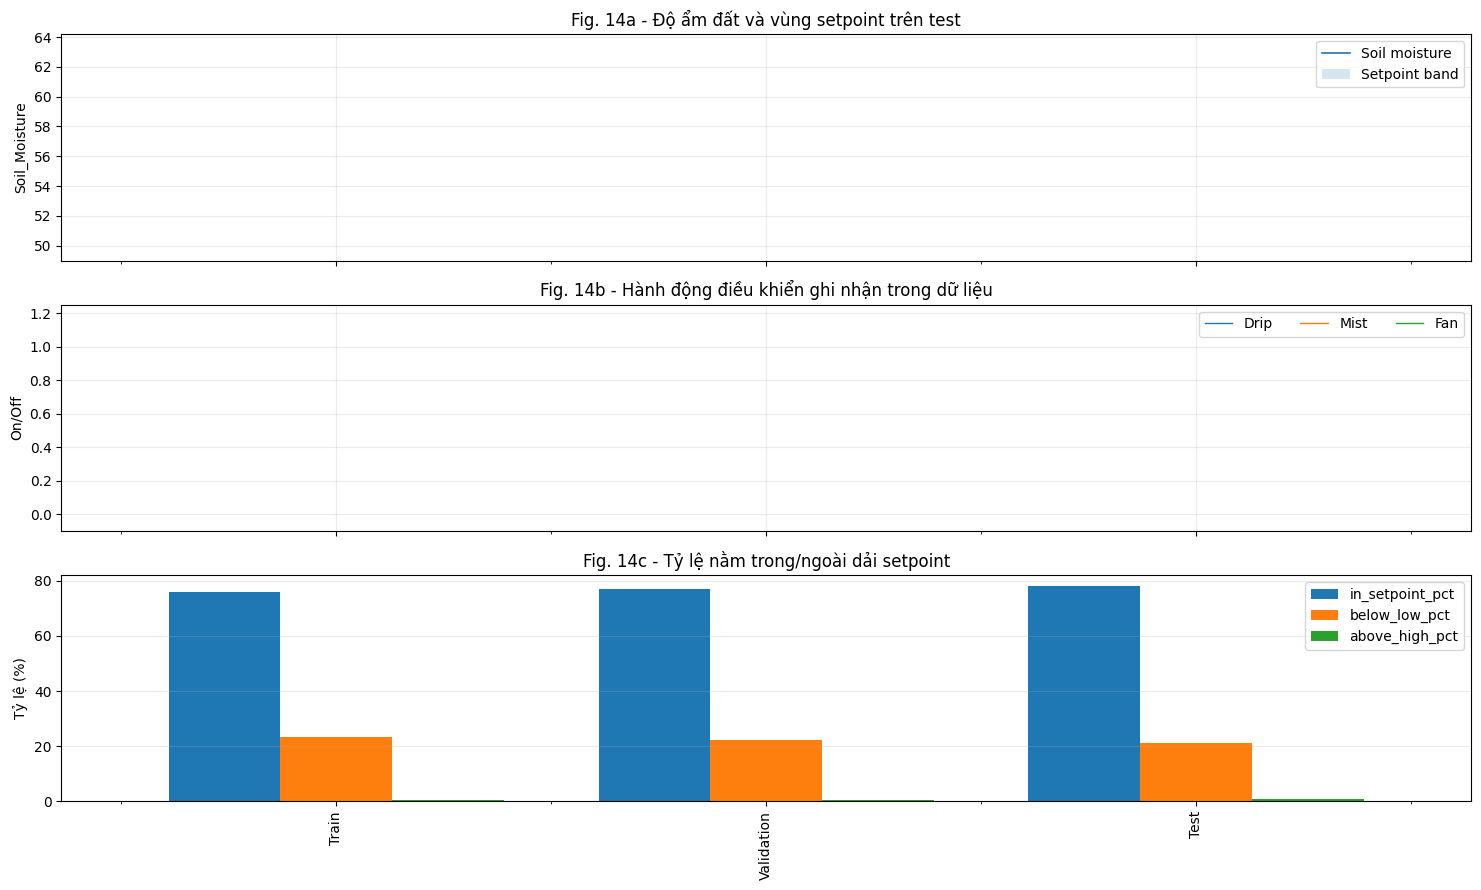

,split,in_setpoint_pct,below_low_pct,above_high_pct,Drip_on_pct,Drip_switches,Mist_on_pct,Mist_switches,Fan_on_pct,Fan_switches
0,Train,75.970,23.489,0.540,23.113,9476,8.335,6324,17.809,9940
1,Validation,77.080,22.425,0.495,22.330,1869,7.445,1158,16.426,1910
2,Test,78.111,21.052,0.837,21.157,1188,5.242,540,10.740,918


In [30]:

def compliance_row(split_name: str, split_df: pd.DataFrame) -> dict:
    y = split_df["Soil_Moisture"].astype(float)
    lo = split_df["Soil_Low_SP"].astype(float)
    hi = split_df["Soil_High_SP"].astype(float)
    in_band = (y >= lo) & (y <= hi)
    row = {"split": split_name, "in_setpoint_pct": 100.0 * float(in_band.mean()), "below_low_pct": 100.0 * float((y < lo).mean()), "above_high_pct": 100.0 * float((y > hi).mean())}
    for col in ["Drip", "Mist", "Fan"]:
        u = split_df[col].astype(float).to_numpy()
        row[f"{col}_on_pct"] = 100.0 * float(np.mean(u))
        row[f"{col}_switches"] = int(np.abs(np.diff(u)).sum()) if len(u) > 1 else 0
    return row

control_summary = pd.DataFrame([compliance_row(name, frame) for name, frame in split_frames]).round(3)
plot_df = df_test_raw.iloc[: 7 * 24 * 12].copy()
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
axes[0].plot(plot_df["Timestamp"], plot_df["Soil_Moisture"], label="Soil moisture", linewidth=1.2)
axes[0].fill_between(plot_df["Timestamp"], plot_df["Soil_Low_SP"], plot_df["Soil_High_SP"], alpha=0.18, label="Setpoint band")
axes[0].set_title("Fig. 14a - Độ ẩm đất và vùng setpoint trên test")
axes[0].set_ylabel("Soil_Moisture")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")
for col in ["Drip", "Mist", "Fan"]:
    axes[1].step(plot_df["Timestamp"], plot_df[col].astype(float), where="post", label=col, linewidth=1.0)
axes[1].set_title("Fig. 14b - Hành động điều khiển ghi nhận trong dữ liệu")
axes[1].set_ylabel("On/Off")
axes[1].set_ylim(-0.1, 1.25)
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncols=3)
control_summary.plot(x="split", y=["in_setpoint_pct", "below_low_pct", "above_high_pct"], kind="bar", ax=axes[2], width=0.78)
axes[2].set_title("Fig. 14c - Tỷ lệ nằm trong/ngoài dải setpoint")
axes[2].set_xlabel("")
axes[2].set_ylabel("Tỷ lệ (%)")
axes[2].grid(True, axis="y", alpha=0.25)
axes[2].legend(title="")
fig.tight_layout()
plt.show()
control_summary


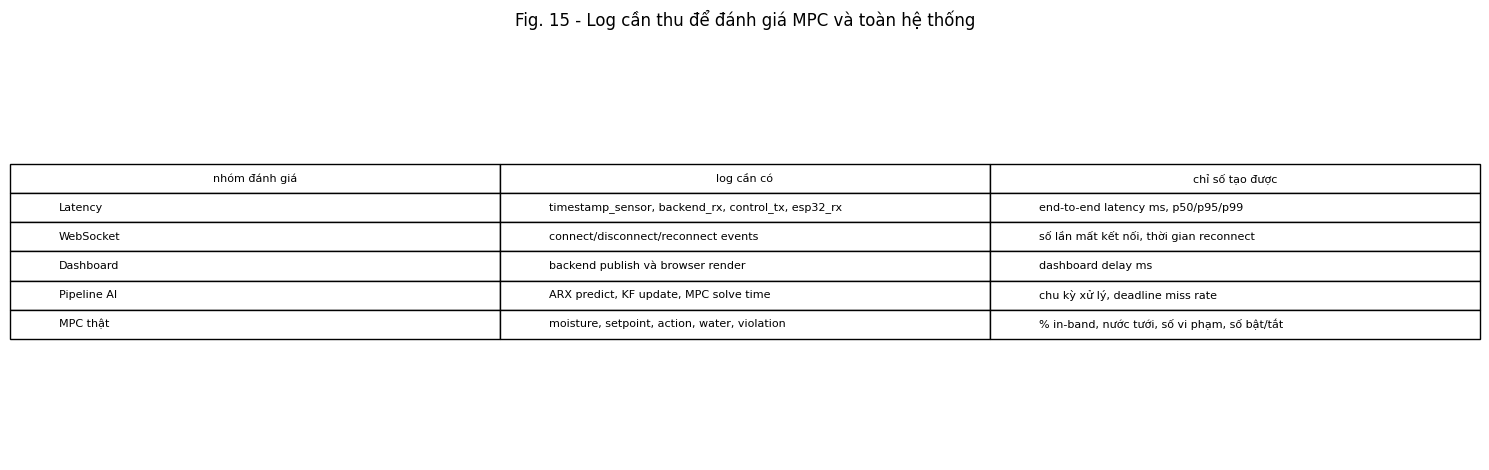

,nhóm đánh giá,log cần có,chỉ số tạo được
0,Latency,"timestamp_sensor, backend_rx, control_tx, esp3...","end-to-end latency ms, p50/p95/p99"
1,WebSocket,connect/disconnect/reconnect events,"số lần mất kết nối, thời gian reconnect"
2,Dashboard,backend publish và browser render,dashboard delay ms
3,Pipeline AI,"ARX predict, KF update, MPC solve time","chu kỳ xử lý, deadline miss rate"
4,MPC thật,"moisture, setpoint, action, water, violation","% in-band, nước tưới, số vi phạm, số bật/tắt"


In [31]:

system_log_requirements = pd.DataFrame([
    {"nhóm đánh giá": "Latency", "log cần có": "timestamp_sensor, backend_rx, control_tx, esp32_rx", "chỉ số tạo được": "end-to-end latency ms, p50/p95/p99"},
    {"nhóm đánh giá": "WebSocket", "log cần có": "connect/disconnect/reconnect events", "chỉ số tạo được": "số lần mất kết nối, thời gian reconnect"},
    {"nhóm đánh giá": "Dashboard", "log cần có": "backend publish và browser render", "chỉ số tạo được": "dashboard delay ms"},
    {"nhóm đánh giá": "Pipeline AI", "log cần có": "ARX predict, KF update, MPC solve time", "chỉ số tạo được": "chu kỳ xử lý, deadline miss rate"},
    {"nhóm đánh giá": "MPC thật", "log cần có": "moisture, setpoint, action, water, violation", "chỉ số tạo được": "% in-band, nước tưới, số vi phạm, số bật/tắt"},
])
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.axis("off")
table = ax.table(cellText=system_log_requirements.values, colLabels=system_log_requirements.columns, loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.55)
ax.set_title("Fig. 15 - Log cần thu để đánh giá MPC và toàn hệ thống", pad=12)
fig.tight_layout()
plt.show()
system_log_requirements


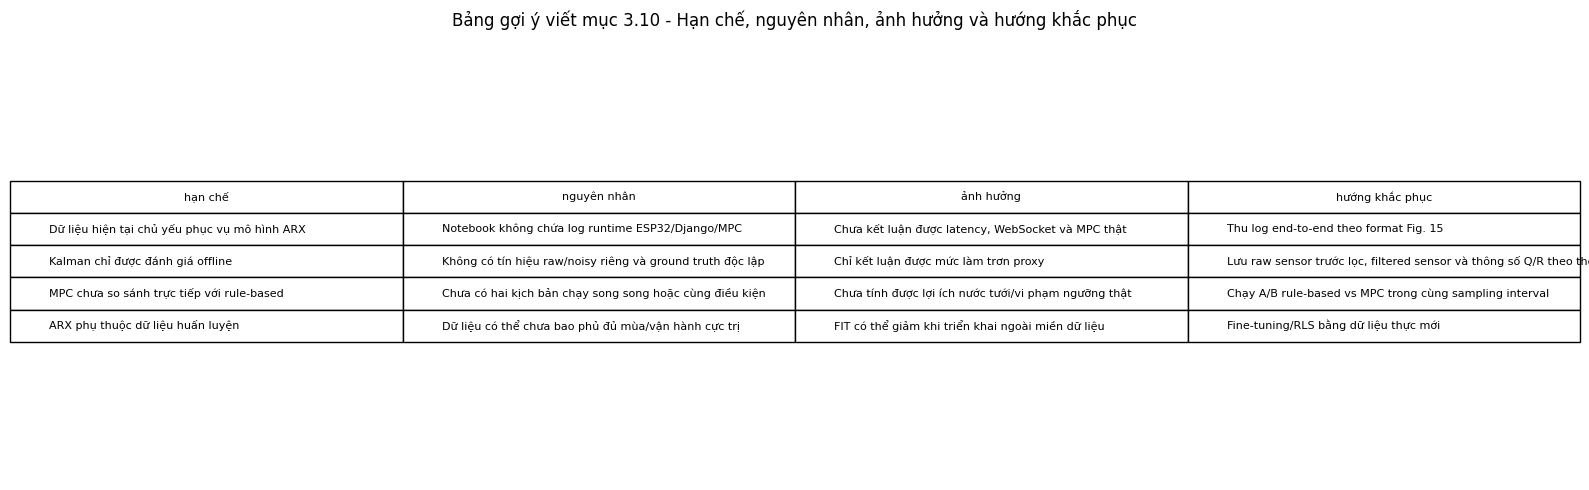

,hạn chế,nguyên nhân,ảnh hưởng,hướng khắc phục
0,Dữ liệu hiện tại chủ yếu phục vụ mô hình ARX,Notebook không chứa log runtime ESP32/Django/MPC,"Chưa kết luận được latency, WebSocket và MPC thật",Thu log end-to-end theo format Fig. 15
1,Kalman chỉ được đánh giá offline,Không có tín hiệu raw/noisy riêng và ground tr...,Chỉ kết luận được mức làm trơn proxy,"Lưu raw sensor trước lọc, filtered sensor và t..."
2,MPC chưa so sánh trực tiếp với rule-based,Chưa có hai kịch bản chạy song song hoặc cùng ...,Chưa tính được lợi ích nước tưới/vi phạm ngưỡn...,Chạy A/B rule-based vs MPC trong cùng sampling...
3,ARX phụ thuộc dữ liệu huấn luyện,Dữ liệu có thể chưa bao phủ đủ mùa/vận hành cự...,FIT có thể giảm khi triển khai ngoài miền dữ liệu,Fine-tuning/RLS bằng dữ liệu thực mới


In [32]:

limitations_df = pd.DataFrame([
    {"hạn chế": "Dữ liệu hiện tại chủ yếu phục vụ mô hình ARX", "nguyên nhân": "Notebook không chứa log runtime ESP32/Django/MPC", "ảnh hưởng": "Chưa kết luận được latency, WebSocket và MPC thật", "hướng khắc phục": "Thu log end-to-end theo format Fig. 15"},
    {"hạn chế": "Kalman chỉ được đánh giá offline", "nguyên nhân": "Không có tín hiệu raw/noisy riêng và ground truth độc lập", "ảnh hưởng": "Chỉ kết luận được mức làm trơn proxy", "hướng khắc phục": "Lưu raw sensor trước lọc, filtered sensor và thông số Q/R theo thời gian"},
    {"hạn chế": "MPC chưa so sánh trực tiếp với rule-based", "nguyên nhân": "Chưa có hai kịch bản chạy song song hoặc cùng điều kiện", "ảnh hưởng": "Chưa tính được lợi ích nước tưới/vi phạm ngưỡng thật", "hướng khắc phục": "Chạy A/B rule-based vs MPC trong cùng sampling interval"},
    {"hạn chế": "ARX phụ thuộc dữ liệu huấn luyện", "nguyên nhân": "Dữ liệu có thể chưa bao phủ đủ mùa/vận hành cực trị", "ảnh hưởng": "FIT có thể giảm khi triển khai ngoài miền dữ liệu", "hướng khắc phục": "Fine-tuning/RLS bằng dữ liệu thực mới"},
])
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")
table = ax.table(cellText=limitations_df.values, colLabels=limitations_df.columns, loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.7)
ax.set_title("Bảng gợi ý viết mục 3.10 - Hạn chế, nguyên nhân, ảnh hưởng và hướng khắc phục", pad=12)
fig.tight_layout()
plt.show()
limitations_df


## 10. Lưu artifact


In [33]:
def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, Path):
        return str(value)
    return value


ar_roots = compute_ar_roots(theta_hat, MODEL_CONFIG)
artifact = {
    "model_type": "ARX",
    "version": VERSION_NAME,
    "version_number": VERSION_NUMBER,
    "notes": "ARX(5,1,2), 16 augmented inputs, missing-data handling, Ridge alpha search, z-score normalization, intercept, free-run clip.",
    "data_source": data_source,
    "data_config": DATA_CONFIG.__dict__,
    "split_config": SPLIT_CONFIG.__dict__,
    "model_config": MODEL_CONFIG.__dict__,
    "missing_data_handling": {
        "enabled": True,
        "continuous_strategy": "linear interpolation + ffill/bfill",
        "binary_strategy": "ffill/bfill then round and clip to 0/1",
        "categorical_strategy": "ffill/bfill",
        "summary": missing_summary.to_dict(orient="records"),
    },
    "feature_engineering": {
        "enabled": USE_AUGMENTED,
        "raw_input_cols": list(BASELINE_INPUT_COLS),
        "input_cols": list(INPUT_COLS),
        "new_features": list(INPUT_COLS[len(BASELINE_INPUT_COLS):]) if USE_AUGMENTED else [],
    },
    "normalization": {
        "enabled": USE_ZSCORE,
        "method": "zscore" if USE_ZSCORE else None,
        "fit_on": "train",
        "scaled_columns": list(SCALE_COLS) if USE_ZSCORE else [],
        "stats": scale_stats if USE_ZSCORE else {},
    },
    "regularization": {
        "method": "ridge" if USE_RIDGE else "ols",
        "alpha_grid": RIDGE_ALPHAS if USE_RIDGE else [0.0],
        "best_alpha": best_alpha,
        "selected_by": "max validation FIT_sim" if USE_RIDGE else "ols",
        "penalize_intercept": False,
    },
    "simulation_clip": {
        "enabled": USE_CLIP,
        "source": "train Soil_Moisture quantiles",
        "quantiles": list(CLIP_QUANTILES),
        "bounds_real": [clip_low_real, clip_high_real],
        "bounds_model": list(clip_bounds_model),
    },
    "param_names": MODEL_CONFIG.param_names,
    "theta_hat": theta_hat.tolist(),
    "sigma2": sigma2_hat,
    "matrix_info": matrix_info.to_dict(),
    "alpha_search": alpha_search_df.to_dict(orient="records"),
    "ar_roots": ar_roots,
    "metrics": {
        "train": {
            "fit_1": train_result["metrics_1step_real"]["FIT"],
            "fit_12": train_result["metrics_12step_real"]["FIT"],
            "fit_sim": train_result["metrics_sim_real"]["FIT"],
            "rmse_sim": train_result["metrics_sim_real"]["RMSE"],
        },
        "validation": {
            "fit_1": val_result["metrics_1step_real"]["FIT"],
            "fit_12": val_result["metrics_12step_real"]["FIT"],
            "fit_sim": val_result["metrics_sim_real"]["FIT"],
            "rmse_sim": val_result["metrics_sim_real"]["RMSE"],
        },
        "test": {
            "fit_1": test_result["metrics_1step_real"]["FIT"],
            "fit_12": test_result["metrics_12step_real"]["FIT"],
            "fit_sim": test_result["metrics_sim_real"]["FIT"],
            "rmse_sim": test_result["metrics_sim_real"]["RMSE"],
        },
    },
    "comparison_512": comparison_df.to_dict(orient="records") if not comparison_df.empty else [],
}

VERSION_DIR.mkdir(exist_ok=True)
output_path = VERSION_DIR / f"arx_512_v{VERSION_NUMBER}.json"
with output_path.open("w", encoding="utf-8") as f:
    json.dump(json_ready(artifact), f, indent=2)
    f.write("\n")

output_path


WindowsPath('C:/Users/minht/OneDrive/Desktop/ARX-Model/ARX_Model_Version 512/arx_512_v7.json')